# 03_multiclass — Мультиклассовая классификация по типам окон атаки

**Цель ноутбука:**  
Обучить мультиклассовые классификаторы (CatBoostClassifier) для предсказания,  
в **каком временном окне** произойдёт ближайшая атака.

**Классы:**

| Класс | Метка | Описание |
|-------|-------|----------|
| 0 | `next_1d` | Атака завтра (≤1 день) — **критическая угроза** |
| 1 | `next_3d` | Атака в течение 2–3 дней — **высокая угроза** |
| 2 | `next_7d` | Атака в течение 4–7 дней — **средняя угроза** |
| 3 | `next_14d` | Атака в течение 8–14 дней — **низкая угроза** |
| 4 | `no_attack_30d` | Атаки не ожидается (> 14 дней или нет в горизонте) |

**Архитектура:**

```
dataset_features.parquet
        ↓
[Для каждого сегмента (infra × threat)]
        ↓
  Временной split (70% train / 15% val / 15% test)
        ↓
  CatBoostClassifier (multi_class, class_weights для дисбаланса)
        ↓
  Оценка: Macro F1, Weighted F1, Accuracy, per-class Recall
        ↓
  Сохранение моделей + метаданных
```

**Входные файлы:**
- `data/interim/dataset_features.parquet`
- `data/interim/feature_meta.json`

**Выходные файлы:**
- `mvp/models/multiclass/<infra>_<threat>.cbm`
- `mvp/models/results_multiclass.csv`


## 1. Установка зависимостей и импорты

In [1]:
!pip install catboost optuna -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
from pathlib import Path

import catboost as cb
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import optuna

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

# Метки классов
ATTACK_WINDOW_LABELS = {
    0: 'next_1d',
    1: 'next_3d',
    2: 'next_7d',
    3: 'next_14d',
    4: 'no_attack_30d'
}
N_CLASSES = 5

print("Все библиотеки загружены")


Все библиотеки загружены


## 2. Загрузка данных

In [3]:
# Ноутбуки в notebooks/, корень проекта — на уровень выше
base_path = Path('..')
data_dir = base_path / 'data' / 'processed'

dataset_model = pd.read_parquet(data_dir / 'dataset_features.parquet')

with open(data_dir / 'feature_meta.json', 'r') as f:
    meta = json.load(f)

feature_cols = meta['feature_cols']
cat_features = meta['cat_features']
TARGET_COL = 'attack_window_class'

# Проверяем наличие целевой переменной
assert TARGET_COL in dataset_model.columns, (
    f"Столбец '{TARGET_COL}' не найден! "
    "Убедитесь, что 02_feature_engineering_v2.ipynb выполнен полностью."
)

print(f"Датасет: {dataset_model.shape}")
print(f"Признаков: {len(feature_cols)}")
print(f"\nРаспределение {TARGET_COL}:")
vc = dataset_model[TARGET_COL].value_counts().sort_index()
for cls, cnt in vc.items():
    pct = cnt / len(dataset_model) * 100
    print(f"  Класс {cls} ({ATTACK_WINDOW_LABELS.get(cls, '?')}): {cnt:>7,} ({pct:.1f}%)")


Датасет: (26112, 51)
Признаков: 21

Распределение attack_window_class:
  Класс 0 (next_1d):   3,579 (13.7%)
  Класс 1 (next_3d):   3,069 (11.8%)
  Класс 2 (next_7d):   4,880 (18.7%)
  Класс 3 (next_14d):   5,689 (21.8%)
  Класс 4 (no_attack_30d):   8,895 (34.1%)


## 3. EDA: распределение классов


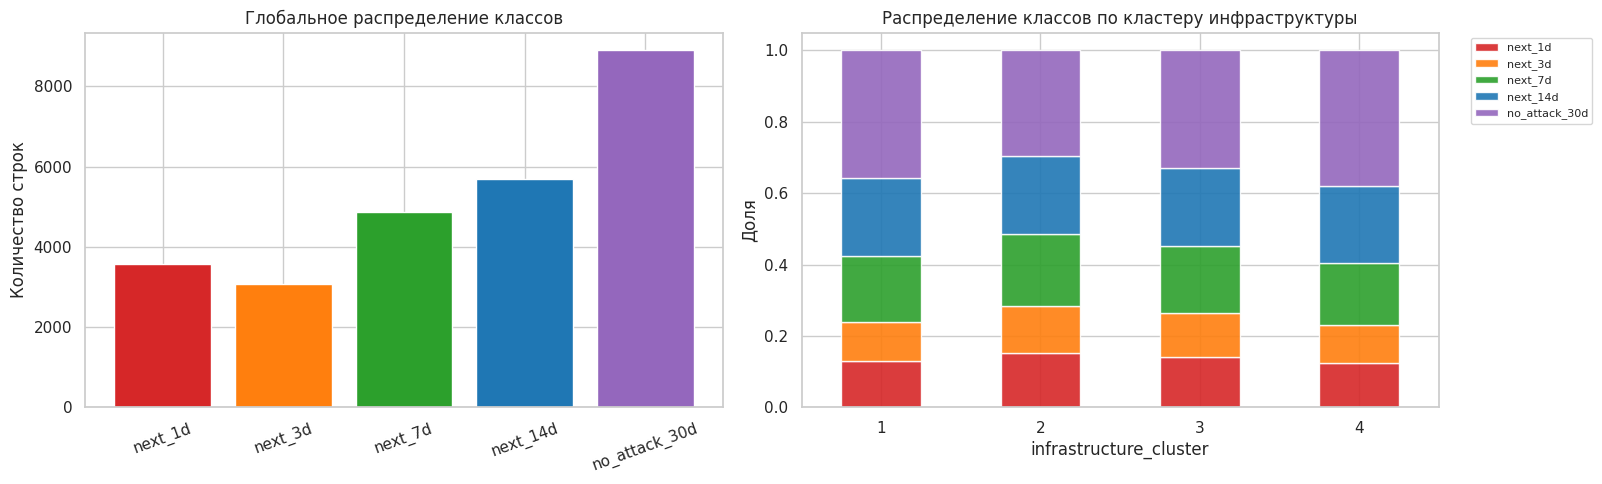


Коэффициент дисбаланса (max/min):
  2.9x


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Глобальное распределение
counts = dataset_model[TARGET_COL].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
labels = [ATTACK_WINDOW_LABELS[i] for i in range(N_CLASSES)]

axes[0].bar(labels, [counts.get(i, 0) for i in range(N_CLASSES)],
            color=colors, edgecolor='white')
axes[0].set_title('Глобальное распределение классов')
axes[0].set_ylabel('Количество строк')
axes[0].tick_params(axis='x', rotation=20)

# Распределение по кластерам инфраструктуры
pivot = dataset_model.groupby(['infrastructure_cluster', TARGET_COL]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='white', alpha=0.9)
axes[1].set_title('Распределение классов по кластеру инфраструктуры')
axes[1].set_ylabel('Доля')
axes[1].set_xlabel('infrastructure_cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend([ATTACK_WINDOW_LABELS[i] for i in range(N_CLASSES)],
               loc='upper right', fontsize=8, bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()

# Дисбаланс по классам
print("\nКоэффициент дисбаланса (max/min):")
print(f"  {counts.max() / counts.min():.1f}x")


## 4. Вспомогательные функции

### Стратегия работы с дисбалансом

Для мультиклассовых задач используем **`class_weights`** в CatBoost:
```python
class_weights = {cls: total / (n_classes * count) for cls, count in counts.items()}
```
Это стандартная `balanced`-стратегия: редкие классы получают больший вес.


In [5]:
# ================================================================
# ЕДИНАЯ add_rolling для всех трёх тренировочных ноутбуков
# Пересчитывает все rolling-зависимые признаки из feature_cols
# без data leakage (shift(1) перед окном).
#
# Требует наличия в df:
#   incidents_count_day, success_count_day, had_incident_today
#   lag_inc_1d (вычисляется внутри функции)
# ================================================================

def add_rolling(df_part: pd.DataFrame) -> pd.DataFrame:
    """
    Пересчитывает все rolling-зависимые признаки для заданного сплита.

    Применяется отдельно к train/val/test, чтобы не было data leakage
    между сплитами. Внутри каждого сплита сортировка по дате сохраняется.

    Признаки (соответствуют feature_meta.json из 02_feature_engineering_v2):
        Скользящие суммы:
            inc_3d_sum, inc_7d_sum, inc_30d_sum
            succ_7d_sum, succ_30d_sum
        Бинарные флаги:
            had_incident_prev_1d, had_incident_prev_3d, had_incident_prev_7d
        Временные (с последнего события):
            days_since_last_incident
        Интенсивность и тренды:
            avg_inter_attack_interval, attack_rate_trend
            streak_active_days, streak_quiet_days
            success_ratio_7d
    """
    import numpy as np
    import pandas as pd

    df_part = df_part.copy()
    grp = df_part.groupby(['infrastructure_cluster', 'threat_cluster'])

    # --- lag_inc_1d (нужен для had_incident_prev_1d) ---
    df_part['lag_inc_1d'] = grp['incidents_count_day'].shift(1).fillna(0)

    # --- Скользящие суммы инцидентов ---
    for window, col in [(3, 'inc_3d_sum'), (7, 'inc_7d_sum'), (30, 'inc_30d_sum')]:
        df_part[col] = (
            grp['incidents_count_day']
            .shift(1)
            .rolling(window, min_periods=1)
            .sum()
            .reset_index(drop=True)
            .fillna(0)
        )

    # --- Скользящие суммы успешных атак ---
    for window, col in [(7, 'succ_7d_sum'), (30, 'succ_30d_sum')]:
        df_part[col] = (
            grp['success_count_day']
            .shift(1)
            .rolling(window, min_periods=1)
            .sum()
            .reset_index(drop=True)
            .fillna(0)
        )

    # --- Бинарные флаги активности ---
    df_part['had_incident_prev_1d'] = (df_part['lag_inc_1d'] > 0).astype(int)
    df_part['had_incident_prev_3d'] = (df_part['inc_3d_sum'] > 0).astype(int)
    df_part['had_incident_prev_7d'] = (df_part['inc_7d_sum'] > 0).astype(int)

    # --- days_since_last_incident ---
    def _days_since_last_event(series: pd.Series) -> pd.Series:
        result = []
        last_day = None
        for i, val in enumerate(series):
            if last_day is None:
                result.append(np.nan)
            else:
                result.append(i - last_day)
            if val > 0:
                last_day = i
        return pd.Series(result, index=series.index)

    df_part['days_since_last_incident'] = (
        grp['had_incident_today']
        .apply(_days_since_last_event)
        .reset_index(level=[0, 1], drop=True)
        .fillna(999)
    )

    # --- avg_inter_attack_interval ---
    df_part['avg_inter_attack_interval'] = (
        grp['days_since_last_incident']
        .shift(1)
        .rolling(30, min_periods=3)
        .mean()
        .reset_index(drop=True)
        .fillna(999)
    )

    # --- attack_rate_trend ---
    df_part['attack_rate_trend'] = (
        df_part['inc_7d_sum'].fillna(0) - df_part['inc_30d_sum'].fillna(0) / (30 / 7)
    )

    # --- streak_active_days / streak_quiet_days ---
    def _calc_streak(series, active=True):
        result = []
        streak = 0
        for val in series:
            condition = (val > 0) if active else (val == 0)
            if condition:
                streak += 1
            else:
                streak = 0
            result.append(streak)
        return pd.Series(result, index=series.index)

    df_part['streak_active_days'] = (
        grp['had_incident_today']
        .shift(1)
        .fillna(0)
        .transform(lambda s: _calc_streak(s, active=True))
    )
    df_part['streak_quiet_days'] = (
        grp['had_incident_today']
        .shift(1)
        .fillna(0)
        .transform(lambda s: _calc_streak(s, active=False))
    )

    # --- success_ratio_7d ---
    df_part['success_ratio_7d'] = np.where(
        df_part['inc_7d_sum'].fillna(0) > 0,
        df_part['succ_7d_sum'].fillna(0) / df_part['inc_7d_sum'].fillna(1),
        0.0
    )

    return df_part

def compute_class_weights(y: np.ndarray, n_classes: int = N_CLASSES) -> dict:
    """
    Вычисляет веса классов по формуле balanced:
    weight_c = N_total / (n_classes × count_c)
    """
    total = len(y)
    weights = {}
    for cls in range(n_classes):
        count = (y == cls).sum()
        if count > 0:
            weights[cls] = total / (n_classes * count)
        else:
            weights[cls] = 1.0
    return weights


print("Функции add_rolling и compute_class_weights определены")


Функции add_rolling и compute_class_weights определены


## 5. Функция обучения мультиклассовых моделей по сегментам

### Ключевые параметры CatBoost для мультикласса:

| Параметр | Значение | Пояснение |
|---------|----------|-----------|
| `loss_function` | `'MultiClass'` | Softmax cross-entropy |
| `eval_metric` | `'TotalF1'` | Macro F1 по всем классам |
| `class_weights` | balanced | Компенсация дисбаланса |

### Метрики оценки:
- **Macro F1** — среднее F1 по всем классам (одинаково взвешены)
- **Weighted F1** — взвешенное по частоте классов
- **Per-class Recall** — критично для класса 0 (`next_1d`): не пропустить критическую угрозу


In [6]:
def train_multiclass_models_by_segments(
    data: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    cat_features: list,
    n_classes: int = N_CLASSES,
    min_rows: int = 120,
    min_classes: int = 3,
    min_class_count: int = 5,
    selected_features: dict | None = None,
    verbose: bool = True
) -> tuple:
    """
    Обучает отдельную LGBMClassifier-модель для каждого сегмента (infra × threat).

    Параметры:
    ----------
    data : pd.DataFrame
        Датасет с признаками и multiclass-таргетом.
    feature_cols : list
        Список имён признаков.
    target_col : str
        Имя multiclass target, например 'attack_window_class'.
    cat_features : list
        Список категориальных признаков.
    n_classes : int
        Общее число классов.
    min_rows : int
        Минимум строк в сегменте.
    min_classes : int
        Минимум уникальных классов в train.
    min_class_count : int
        Минимальное число объектов в самом редком классе train.
    selected_features : dict | None
        Словарь {(infra, threat): [features]} для сегментных фичей.
    verbose : bool
        Выводить лог или нет.

    Возвращает:
    ----------
    models : dict
        {(infra, threat): LGBMClassifier}
    results_df : pd.DataFrame
        Таблица метрик по сегментам.
    """
    import numpy as np
    import pandas as pd
    import lightgbm as lgb

    from lightgbm import LGBMClassifier
    from sklearn.metrics import f1_score, accuracy_score

    models = {}
    results = []

    infra_values = sorted(data['infrastructure_cluster'].astype(str).unique())
    threat_values = sorted(data['threat_cluster'].dropna().astype(int).unique())

    for infra_value in infra_values:
        for threat_value in threat_values:

            part = data[
                (data['infrastructure_cluster'].astype(str) == str(infra_value)) &
                (data['threat_cluster'].astype(int) == int(threat_value))
            ].copy()

            n_rows = len(part)
            seg_label = f"infra={infra_value}, threat={threat_value}"

            if verbose:
                print(f"\n{'='*80}")
                print(f"Сегмент: {seg_label} | target={target_col}")
                print(f"  Строк: {n_rows}")

            if n_rows < min_rows:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: слишком мало строк (нужно >= {min_rows})")
                continue

            part = part.sort_values('date').reset_index(drop=True)

            unique_dates = np.array(sorted(part['date'].unique()))
            n_dates = len(unique_dates)

            if n_dates < 30:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: мало уникальных дат ({n_dates} < 30)")
                continue

            train_end = int(n_dates * 0.70)
            val_end   = int(n_dates * 0.85)

            train_dates = unique_dates[:train_end]
            val_dates   = unique_dates[train_end:val_end]
            test_dates  = unique_dates[val_end:]

            train_df = part[part['date'].isin(train_dates)].copy()
            val_df   = part[part['date'].isin(val_dates)].copy()
            test_df  = part[part['date'].isin(test_dates)].copy()

            train_df = add_rolling(train_df)
            val_df   = add_rolling(val_df)
            test_df  = add_rolling(test_df)

            if verbose:
                print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

            y_train = train_df[target_col].astype(int).copy()
            y_val   = val_df[target_col].astype(int).copy()
            y_test  = test_df[target_col].astype(int).copy()

            n_unique = y_train.nunique()
            class_counts = y_train.value_counts().sort_index()

            if n_unique < min_classes:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: мало классов в train ({n_unique} < {min_classes})")
                continue

            if class_counts.min() < min_class_count:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: слишком мало объектов в редком классе train "
                          f"({class_counts.min()} < {min_class_count})")
                continue

            segment_key = (int(infra_value), int(threat_value))
            if selected_features is not None and segment_key in selected_features:
                segment_feature_cols = selected_features[segment_key]
            else:
                segment_feature_cols = feature_cols

            avail_feats = [f for f in segment_feature_cols if f in train_df.columns]
            local_cats = [c for c in cat_features if c in avail_feats]

            def prep(df):
                X = df[avail_feats].copy()
                for c in local_cats:
                    X[c] = X[c].astype('category')
                return X

            X_train = prep(train_df)
            X_val   = prep(val_df)
            X_test  = prep(test_df)

            class_weights = compute_class_weights(y_train.values, n_classes=n_classes)

            model = LGBMClassifier(
                objective='multiclass',
                num_class=n_classes,
                class_weight=class_weights,
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                num_leaves=31,
                min_child_samples=30,
                min_child_weight=1e-2,
                subsample=0.8,
                subsample_freq=1,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=3.0,
                min_split_gain=0.01,
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
                deterministic=True,
                force_col_wise=True
            )

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='multi_logloss',
                categorical_feature=local_cats if len(local_cats) > 0 else 'auto',
                callbacks=[lgb.early_stopping(50, verbose=False)]
            )

            val_pred  = model.predict(X_val).astype(int)
            test_pred = model.predict(X_test).astype(int)

            def get_metrics(y_true, y_pred, prefix):
                macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
                weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                acc = accuracy_score(y_true, y_pred)

                per_class = {}
                for cls in range(n_classes):
                    mask = (y_true == cls)
                    if mask.sum() > 0:
                        recall_c = (y_pred[mask] == cls).mean()
                    else:
                        recall_c = np.nan
                    per_class[f'{prefix}_recall_cls{cls}'] = recall_c

                per_class_precision = {}
                per_class_f1 = {}
                for cls in range(n_classes):
                    tp = ((y_pred == cls) & (y_true == cls)).sum()
                    fp = ((y_pred == cls) & (y_true != cls)).sum()
                    fn = ((y_pred != cls) & (y_true == cls)).sum()

                    precision_c = tp / (tp + fp) if (tp + fp) > 0 else np.nan
                    recall_c = per_class[f'{prefix}_recall_cls{cls}']

                    if not np.isnan(precision_c) and not np.isnan(recall_c) and (precision_c + recall_c) > 0:
                        f1_c = 2 * precision_c * recall_c / (precision_c + recall_c)
                    else:
                        f1_c = np.nan

                    per_class_precision[f'{prefix}_precision_cls{cls}'] = precision_c
                    per_class_f1[f'{prefix}_f1_cls{cls}'] = f1_c

                return {
                    f'{prefix}_macro_f1': macro_f1,
                    f'{prefix}_weighted_f1': weighted_f1,
                    f'{prefix}_accuracy': acc,
                    **per_class,
                    **per_class_precision,
                    **per_class_f1
                }

            m_val = get_metrics(y_val.values, val_pred, 'val')
            m_test = get_metrics(y_test.values, test_pred, 'test')

            if verbose:
                print(f"  Val:  macro_F1={m_val['val_macro_f1']:.4f} "
                      f"weighted_F1={m_val['val_weighted_f1']:.4f} "
                      f"acc={m_val['val_accuracy']:.4f}")
                print(f"  Test: macro_F1={m_test['test_macro_f1']:.4f} "
                      f"weighted_F1={m_test['test_weighted_f1']:.4f} "
                      f"acc={m_test['test_accuracy']:.4f}")

            models[(str(infra_value), int(threat_value))] = model
            results.append({
                'infrastructure_cluster': str(infra_value),
                'threat_cluster': int(threat_value),
                'target': target_col,
                'n_rows': n_rows,
                'n_train': len(train_df),
                'n_val': len(val_df),
                'n_test': len(test_df),
                'n_unique_classes_train': int(n_unique),
                'min_class_count_train': int(class_counts.min()),
                'best_iteration': int(model.best_iteration_) if hasattr(model, 'best_iteration_') and model.best_iteration_ is not None else None,
                **{k: round(v, 4) if isinstance(v, (float, np.floating)) and not np.isnan(v) else v
                   for k, v in m_val.items()},
                **{k: round(v, 4) if isinstance(v, (float, np.floating)) and not np.isnan(v) else v
                   for k, v in m_test.items()},
            })

    results_df = pd.DataFrame(results)
    return models, results_df


print("Функция train_multiclass_lgbm_models_by_segments определена")

Функция train_multiclass_lgbm_models_by_segments определена


## 6. Обучение мультиклассовых моделей

Предсказываем: **в каком временном окне ожидается ближайшая атака?**

Классы упорядочены по срочности — от «атака завтра» до «нет угрозы в 30-дневном горизонте».


In [7]:
print("Обучение мультиклассовых моделей (attack_window_class)...")
print(f"Сегментов для обхода: "
      f"{dataset_model['infrastructure_cluster'].nunique()} × "
      f"{dataset_model['threat_cluster'].nunique()}")

models_mc, results_mc = train_multiclass_models_by_segments(
    data=dataset_model,
    feature_cols=feature_cols,
    target_col=TARGET_COL,
    cat_features=cat_features,
    n_classes=N_CLASSES,
    min_rows=120,
    min_classes=3,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Обучено моделей: {len(models_mc)}")
print(f"\nТаблица результатов (по убыванию Macro F1):")
display(results_mc.sort_values('test_macro_f1', ascending=False).round(4))


Обучение мультиклассовых моделей (attack_window_class)...
Сегментов для обхода: 4 × 6

Сегмент: infra=1, threat=1 | target=attack_window_class
  Строк: 1088
  Train: 761 | Val: 163 | Test: 164
  Val:  macro_F1=0.1688 weighted_F1=0.2073 acc=0.2761
  Test: macro_F1=0.1855 weighted_F1=0.3230 acc=0.3902

Сегмент: infra=1, threat=2 | target=attack_window_class
  Строк: 1088
  Train: 761 | Val: 163 | Test: 164
  Val:  macro_F1=0.0833 weighted_F1=0.0880 acc=0.1718
  Test: macro_F1=0.1952 weighted_F1=0.3484 acc=0.4878

Сегмент: infra=1, threat=3 | target=attack_window_class
  Строк: 1088
  Train: 761 | Val: 163 | Test: 164
  Val:  macro_F1=0.2055 weighted_F1=0.1881 acc=0.2638
  Test: macro_F1=0.1388 weighted_F1=0.2045 acc=0.2561

Сегмент: infra=1, threat=4 | target=attack_window_class
  Строк: 1088
  Train: 761 | Val: 163 | Test: 164
  Val:  macro_F1=0.1779 weighted_F1=0.2057 acc=0.2147
  Test: macro_F1=0.1520 weighted_F1=0.2754 acc=0.3293

Сегмент: infra=1, threat=5 | target=attack_window_cla

,infrastructure_cluster,threat_cluster,target,n_rows,n_train,n_val,n_test,n_unique_classes_train,min_class_count_train,best_iteration,...,test_precision_cls0,test_precision_cls1,test_precision_cls2,test_precision_cls3,test_precision_cls4,test_f1_cls0,test_f1_cls1,test_f1_cls2,test_f1_cls3,test_f1_cls4
15,3,4,attack_window_class,1088,761,163,164,5,114,6,...,0.1481,0.4000,0.4667,0.5455,0.7857,0.2353,0.2667,0.5600,0.5294,0.5197
12,3,1,attack_window_class,1088,761,163,164,5,87,6,...,0.2000,0.3333,0.5000,0.3696,0.6346,0.1622,0.0870,0.0606,0.5191,0.6346
16,3,5,attack_window_class,1088,761,163,164,5,86,1,...,NaN,0.1867,0.0833,0.2500,0.6098,NaN,0.2887,0.0727,0.3000,0.4673
4,1,5,attack_window_class,1088,761,163,164,5,91,7,...,0.0000,0.2000,0.2069,0.4043,0.0000,NaN,0.2985,0.2759,0.4176,NaN
1,1,2,attack_window_class,1088,761,163,164,5,81,4,...,NaN,NaN,0.6667,0.3333,0.4839,NaN,NaN,0.2667,0.0571,0.6522
0,1,1,attack_window_class,1088,761,163,164,5,70,25,...,0.1667,0.0000,0.0000,0.0870,0.5437,0.2143,NaN,NaN,0.0769,0.6364
23,4,6,attack_window_class,1088,761,163,164,5,73,9,...,0.2143,0.0000,0.0000,0.0870,0.5361,0.1935,NaN,NaN,0.1067,0.5843
14,3,3,attack_window_class,1088,761,163,164,5,88,1,...,0.1714,0.0909,0.2000,0.1579,0.2195,0.1967,0.0571,0.1633,0.2195,0.1782
19,4,2,attack_window_class,1088,761,163,164,5,89,1,...,0.2041,0.1585,0.1333,0.2778,NaN,0.2817,0.2549,0.0800,0.1562,NaN
21,4,4,attack_window_class,1088,761,163,164,5,87,18,...,0.1667,0.0000,0.0000,0.2222,0.3364,0.1818,NaN,NaN,0.1231,0.4586


In [8]:
models_mc

{('1',
  1): LGBMClassifier(class_weight={0: np.float64(1.9265822784810127),
                              1: np.float64(2.1742857142857144),
                              2: np.float64(1.3589285714285715),
                              3: np.float64(1.0214765100671142),
                              4: np.float64(0.4336182336182336)},
                colsample_bytree=0.8, deterministic=True, force_col_wise=True,
                learning_rate=0.05, max_depth=6, min_child_samples=30,
                min_child_weight=0.01, min_split_gain=0.01, n_estimators=500,
                n_jobs=-1, num_class=5, objective='multiclass', random_state=42,
                reg_alpha=0.1, reg_lambda=3.0, subsample=0.8, subsample_freq=1,
                verbosity=-1),
 ('1',
  2): LGBMClassifier(class_weight={0: np.float64(1.7697674418604652),
                              1: np.float64(1.8790123456790124),
                              2: np.float64(1.1443609022556391),
                              3: np

## 7. Анализ результатов

### Интерпретация метрик

| Метрика | Значение |
|---------|----------|
| **Macro F1** | Среднее F1 по всем классам. Строгая метрика — чувствительна к редким классам |
| **Weighted F1** | F1, взвешенный по частоте классов. Ближе к общей точности |
| **Accuracy** | Доля правильных ответов. Не показательна при дисбалансе |
| **Recall класса 0** | Доля угроз «следующего дня», которые модель поймала. **Ключевая метрика!** |

Для задачи ИБ: **Recall класса 0 ≥ 0.7** — приоритет, даже ценой большего числа ложных тревог.


=== Сводная статистика метрик ===

test_macro_f1: mean=0.159, median=0.143, min=0.071, max=0.422
test_weighted_f1: mean=0.207, median=0.179, min=0.054, max=0.487
test_accuracy: mean=0.252, median=0.235, min=0.085, max=0.488
test_recall_cls0: mean=0.175, median=0.156, min=0.000, max=0.710
test_recall_cls4: mean=0.436, median=0.445, min=0.000, max=1.000


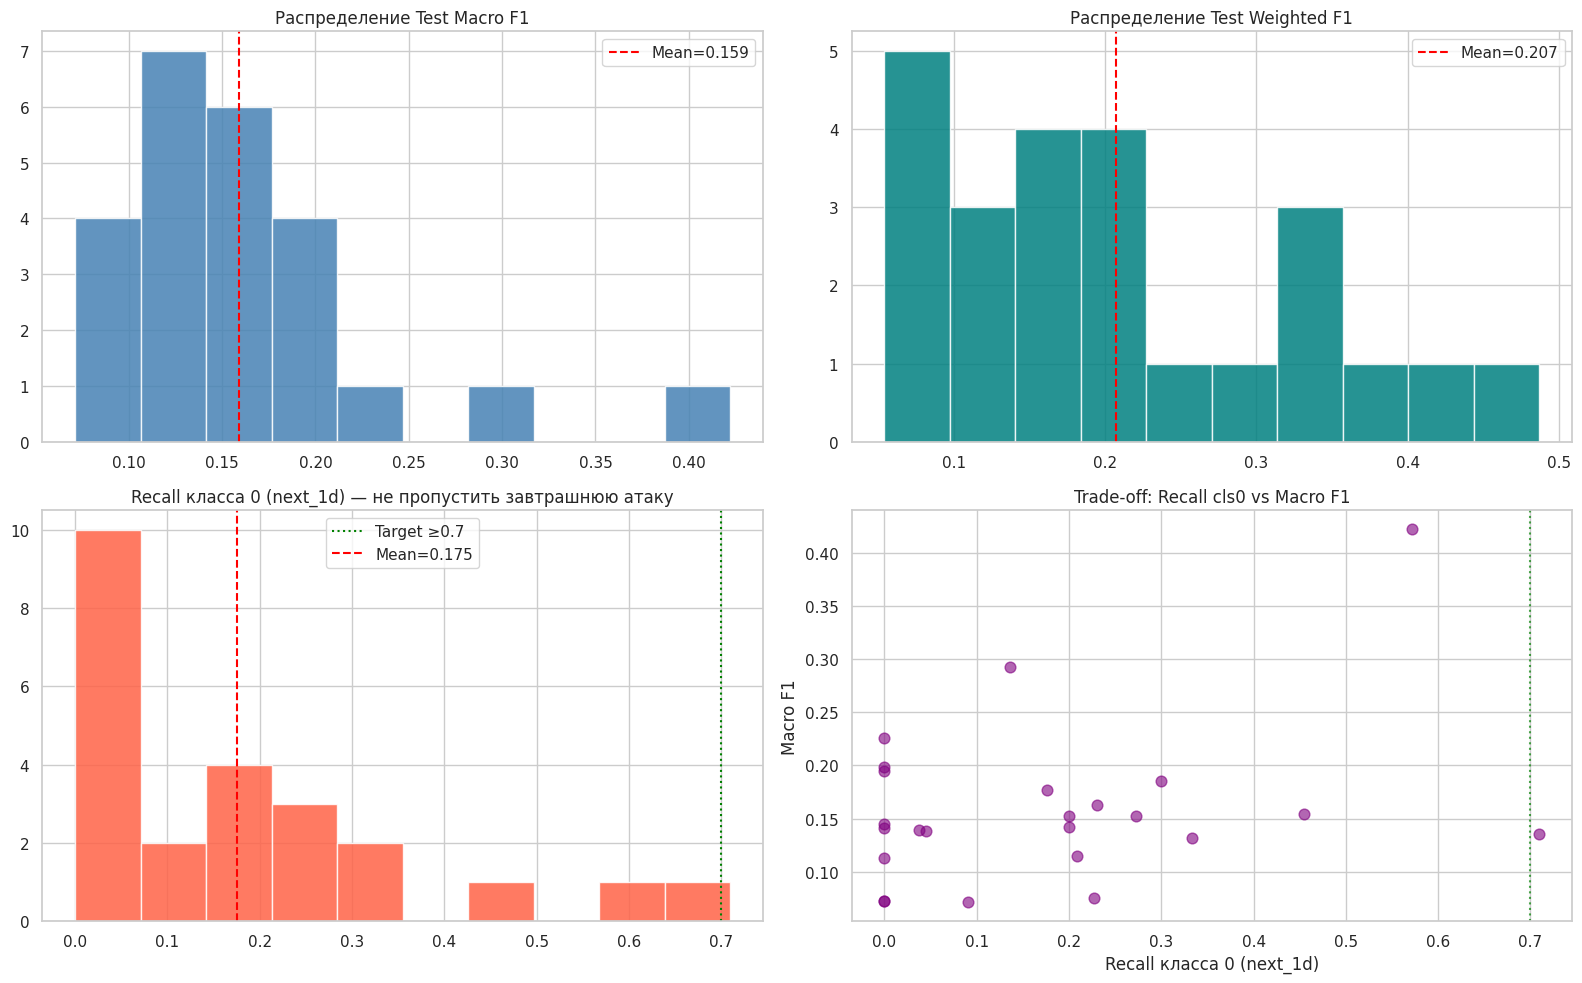

In [9]:
if len(results_mc) == 0:
    print("Нет обученных моделей — проверьте данные")
else:
    print("=== Сводная статистика метрик ===\n")
    for m in ['test_macro_f1', 'test_weighted_f1', 'test_accuracy',
              'test_recall_cls0', 'test_recall_cls4']:
        s = results_mc[m].dropna()
        if len(s) > 0:
            print(f"{m}: mean={s.mean():.3f}, median={s.median():.3f}, "
                  f"min={s.min():.3f}, max={s.max():.3f}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Macro F1
    axes[0,0].hist(results_mc['test_macro_f1'].dropna(), bins=10,
                   color='steelblue', edgecolor='white', alpha=0.85)
    axes[0,0].axvline(results_mc['test_macro_f1'].mean(), color='red',
                      linestyle='--', label=f"Mean={results_mc['test_macro_f1'].mean():.3f}")
    axes[0,0].set_title('Распределение Test Macro F1')
    axes[0,0].legend()

    # Weighted F1
    axes[0,1].hist(results_mc['test_weighted_f1'].dropna(), bins=10,
                   color='teal', edgecolor='white', alpha=0.85)
    axes[0,1].axvline(results_mc['test_weighted_f1'].mean(), color='red',
                      linestyle='--', label=f"Mean={results_mc['test_weighted_f1'].mean():.3f}")
    axes[0,1].set_title('Распределение Test Weighted F1')
    axes[0,1].legend()

    # Recall класса 0 (next_1d) — критически важный
    if 'test_recall_cls0' in results_mc.columns:
        axes[1,0].hist(results_mc['test_recall_cls0'].dropna(), bins=10,
                       color='tomato', edgecolor='white', alpha=0.85)
        axes[1,0].axvline(0.7, color='green', linestyle=':', label='Target ≥0.7')
        mean_r0 = results_mc['test_recall_cls0'].mean()
        axes[1,0].axvline(mean_r0, color='red',
                          linestyle='--', label=f"Mean={mean_r0:.3f}")
        axes[1,0].set_title('Recall класса 0 (next_1d) — не пропустить завтрашнюю атаку')
        axes[1,0].legend()

    # Scatter Macro F1 vs Recall cls0
    if 'test_recall_cls0' in results_mc.columns:
        axes[1,1].scatter(results_mc['test_recall_cls0'],
                          results_mc['test_macro_f1'],
                          alpha=0.6, color='purple', s=60)
        axes[1,1].axvline(0.7, color='green', linestyle=':', alpha=0.7)
        axes[1,1].set_xlabel('Recall класса 0 (next_1d)')
        axes[1,1].set_ylabel('Macro F1')
        axes[1,1].set_title('Trade-off: Recall cls0 vs Macro F1')

    plt.tight_layout()
    plt.show()


## 8. Confusion Matrix лучшего сегмента

Сегмент: infra=3, threat=4
Test Macro F1: 0.4222



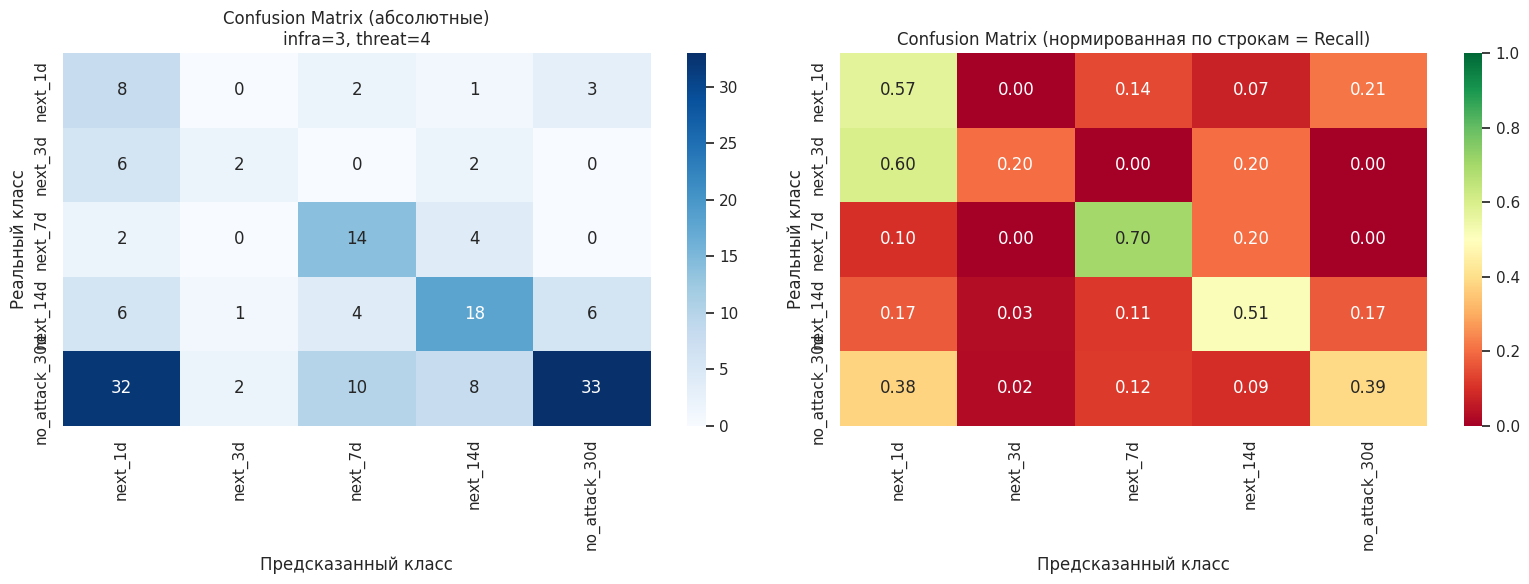


Classification Report:
               precision    recall  f1-score   support

      next_1d       0.15      0.57      0.24        14
      next_3d       0.40      0.20      0.27        10
      next_7d       0.47      0.70      0.56        20
     next_14d       0.55      0.51      0.53        35
no_attack_30d       0.79      0.39      0.52        85

     accuracy                           0.46       164
    macro avg       0.47      0.47      0.42       164
 weighted avg       0.62      0.46      0.49       164



In [10]:
if len(results_mc) > 0:
    best_row = results_mc.loc[results_mc['test_macro_f1'].idxmax()]
    infra_v  = str(best_row['infrastructure_cluster'])
    threat_v = int(best_row['threat_cluster'])

    part = dataset_model[
        (dataset_model['infrastructure_cluster'].astype(str) == infra_v) &
        (dataset_model['threat_cluster'].astype(int) == threat_v)
    ].copy().sort_values('date').reset_index(drop=True)

    unique_dates = np.array(sorted(part['date'].unique()))
    n = len(unique_dates)
    test_dates = unique_dates[int(n * 0.85):]

    test_df = add_rolling(part[part['date'].isin(test_dates)].copy())
    avail_feats = [f for f in feature_cols if f in test_df.columns]
    X_test = test_df[avail_feats].copy()
    local_cats = [c for c in cat_features if c in X_test.columns]
    for c in local_cats:
        X_test[c] = X_test[c].astype(str)

    model = models_mc[(infra_v, threat_v)]
    y_pred = model.predict(X_test).flatten().astype(int)
    y_true = test_df[TARGET_COL].values.astype(int)

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Сегмент: infra={infra_v}, threat={threat_v}")
    print(f"Test Macro F1: {macro_f1:.4f}\n")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Абсолютные значения
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=list(ATTACK_WINDOW_LABELS.values()),
                yticklabels=list(ATTACK_WINDOW_LABELS.values()))
    axes[0].set_title(f'Confusion Matrix (абсолютные)\ninfra={infra_v}, threat={threat_v}')
    axes[0].set_ylabel('Реальный класс')
    axes[0].set_xlabel('Предсказанный класс')

    # Нормированные по строкам (Recall по классам)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
                vmin=0, vmax=1,
                xticklabels=list(ATTACK_WINDOW_LABELS.values()),
                yticklabels=list(ATTACK_WINDOW_LABELS.values()))
    axes[1].set_title('Confusion Matrix (нормированная по строкам = Recall)')
    axes[1].set_ylabel('Реальный класс')
    axes[1].set_xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        labels=list(range(N_CLASSES)),
        target_names=list(ATTACK_WINDOW_LABELS.values()),
        zero_division=0
    ))


## 9. Heatmap Macro F1 по сегментам

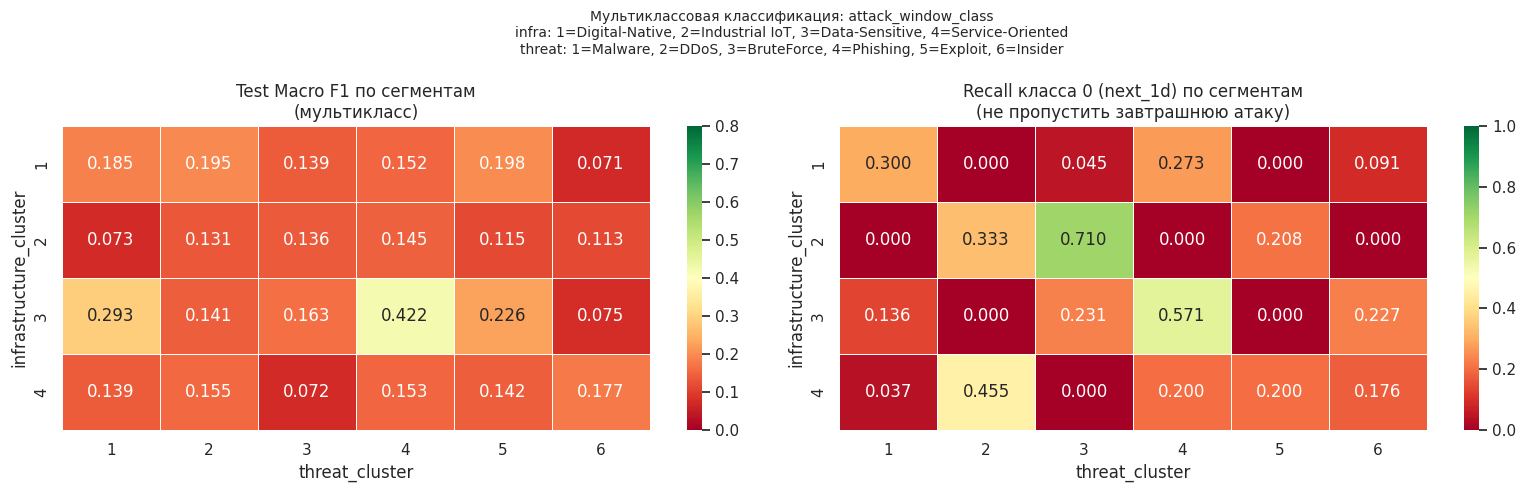

In [11]:
if len(results_mc) > 0:
    pivot_f1 = results_mc.pivot(
        index='infrastructure_cluster',
        columns='threat_cluster',
        values='test_macro_f1'
    )

    pivot_r0 = results_mc.pivot(
        index='infrastructure_cluster',
        columns='threat_cluster',
        values='test_recall_cls0'
    ) if 'test_recall_cls0' in results_mc.columns else None

    n_plots = 2 if pivot_r0 is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=0.8, ax=axes[0],
                linewidths=0.5, mask=pivot_f1.isna())
    axes[0].set_title('Test Macro F1 по сегментам\n(мультикласс)')

    if pivot_r0 is not None:
        sns.heatmap(pivot_r0, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=0, vmax=1.0, ax=axes[1],
                    linewidths=0.5, mask=pivot_r0.isna())
        axes[1].set_title('Recall класса 0 (next_1d) по сегментам\n(не пропустить завтрашнюю атаку)')

    plt.suptitle('Мультиклассовая классификация: attack_window_class\n'
                 'infra: 1=Digital-Native, 2=Industrial IoT, 3=Data-Sensitive, 4=Service-Oriented\n'
                 'threat: 1=Malware, 2=DDoS, 3=BruteForce, 4=Phishing, 5=Exploit, 6=Insider',
                 fontsize=10)
    plt.tight_layout()
    plt.show()


## 10. Важность признаков

Feature Importance (infra=1, threat=1):


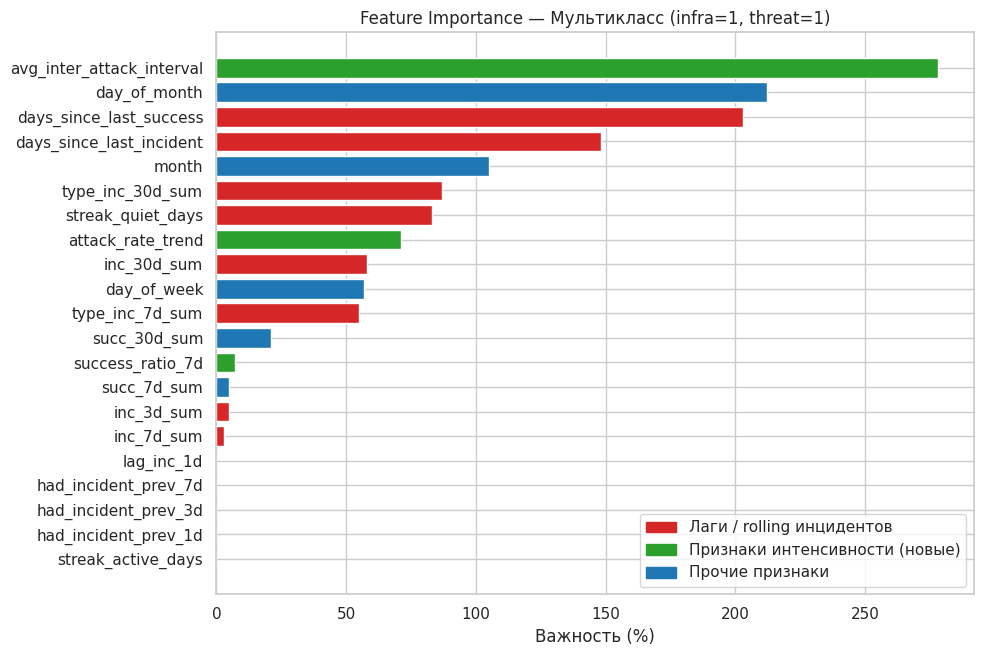


Топ-10 признаков:


,feature,importance
16,avg_inter_attack_interval,278
1,day_of_month,212
13,days_since_last_success,203
12,days_since_last_incident,148
2,month,105
15,type_inc_30d_sum,87
19,streak_quiet_days,83
17,attack_rate_trend,71
6,inc_30d_sum,58
0,day_of_week,57


In [12]:
if models_mc:
    sample_key = list(models_mc.keys())[0]
    model = models_mc[sample_key]

    importance_df = pd.DataFrame({
        'feature': model.feature_name_,
        'importance': model.booster_.feature_importance()
    }).sort_values('importance', ascending=False)

    print(f"Feature Importance (infra={sample_key[0]}, threat={sample_key[1]}):")

    fig, ax = plt.subplots(figsize=(10, max(6, len(importance_df) * 0.32)))
    colors = ['#d62728' if any(kw in f for kw in ['inc_', 'days_since', 'streak', 'lag_days'])
              else '#2ca02c' if any(kw in f for kw in ['attack_rate', 'success_ratio', 'avg_inter'])
              else '#1f77b4'
              for f in importance_df['feature']]
    ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance — Мультикласс (infra={sample_key[0]}, threat={sample_key[1]})')
    ax.set_xlabel('Важность (%)')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(color='#d62728', label='Лаги / rolling инцидентов'),
        Patch(color='#2ca02c', label='Признаки интенсивности (новые)'),
        Patch(color='#1f77b4', label='Прочие признаки'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 признаков:")
    display(importance_df.head(10))



Feature Importance (infra=1, threat=1):


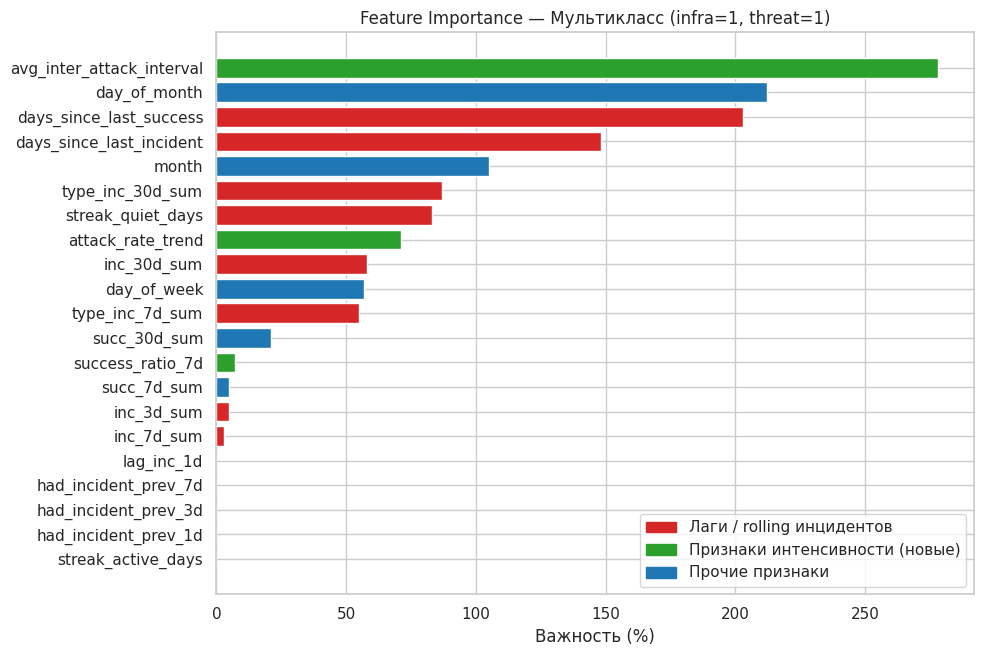

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,278,1,1
1,day_of_month,212,1,1
2,days_since_last_success,203,1,1
3,days_since_last_incident,148,1,1
4,month,105,1,1
5,type_inc_30d_sum,87,1,1
6,streak_quiet_days,83,1,1
7,attack_rate_trend,71,1,1
8,inc_30d_sum,58,1,1
9,day_of_week,57,1,1



Feature Importance (infra=1, threat=2):


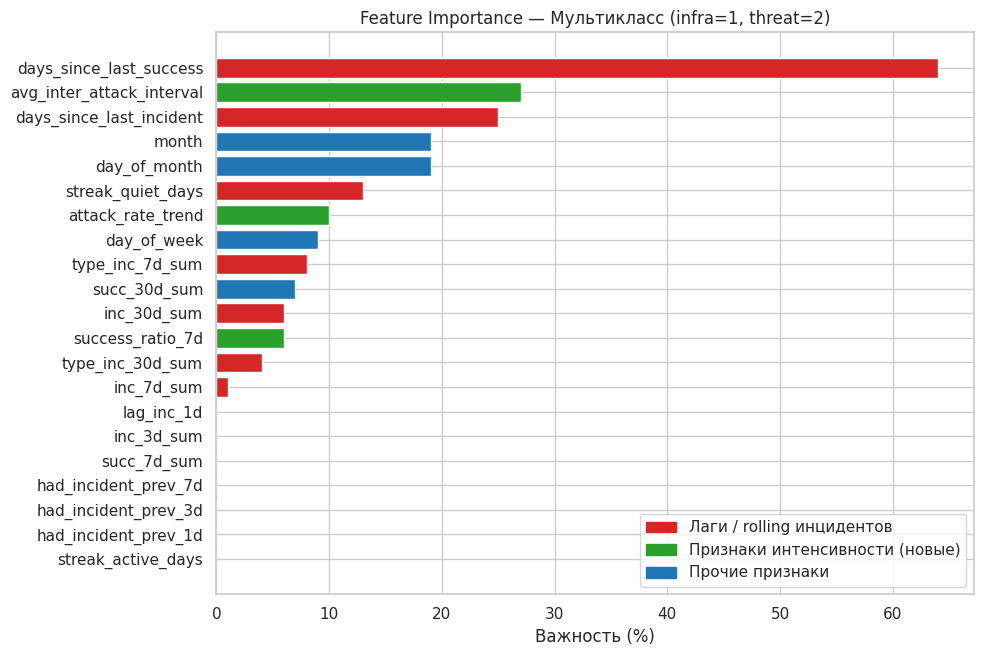

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,64,1,2
1,avg_inter_attack_interval,27,1,2
2,days_since_last_incident,25,1,2
3,month,19,1,2
4,day_of_month,19,1,2
5,streak_quiet_days,13,1,2
6,attack_rate_trend,10,1,2
7,day_of_week,9,1,2
8,type_inc_7d_sum,8,1,2
9,succ_30d_sum,7,1,2



Feature Importance (infra=1, threat=3):


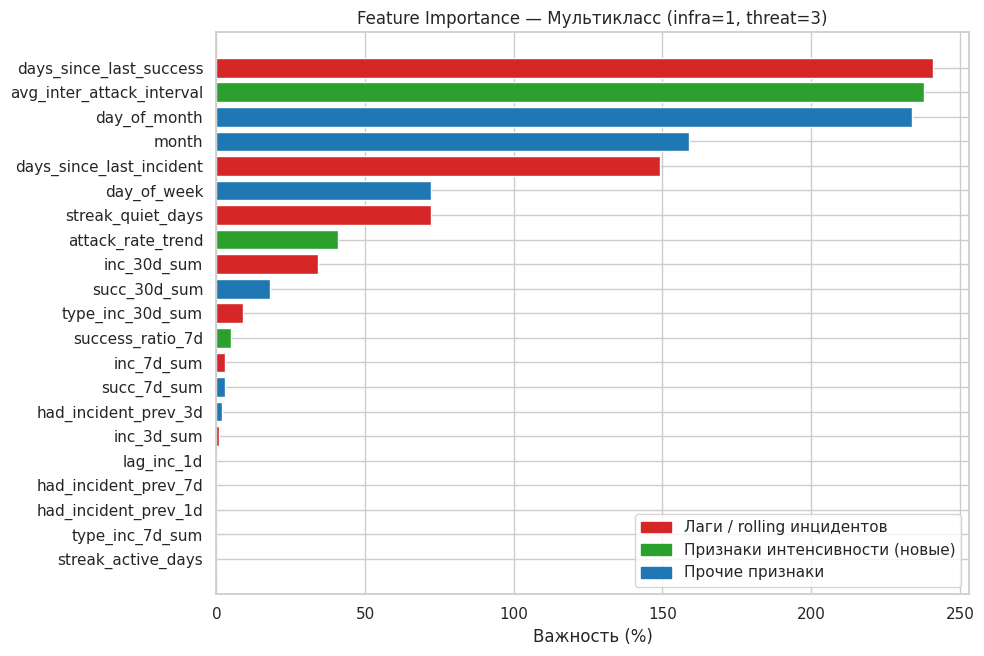

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,241,1,3
1,avg_inter_attack_interval,238,1,3
2,day_of_month,234,1,3
3,month,159,1,3
4,days_since_last_incident,149,1,3
5,day_of_week,72,1,3
6,streak_quiet_days,72,1,3
7,attack_rate_trend,41,1,3
8,inc_30d_sum,34,1,3
9,succ_30d_sum,18,1,3



Feature Importance (infra=1, threat=4):


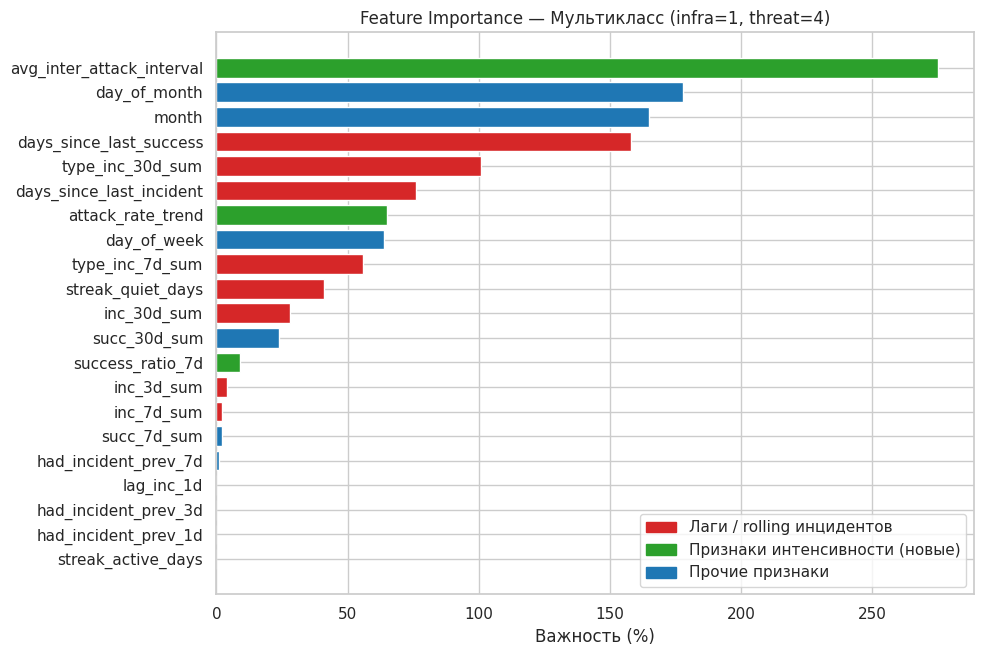

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,275,1,4
1,day_of_month,178,1,4
2,month,165,1,4
3,days_since_last_success,158,1,4
4,type_inc_30d_sum,101,1,4
5,days_since_last_incident,76,1,4
6,attack_rate_trend,65,1,4
7,day_of_week,64,1,4
8,type_inc_7d_sum,56,1,4
9,streak_quiet_days,41,1,4



Feature Importance (infra=1, threat=5):


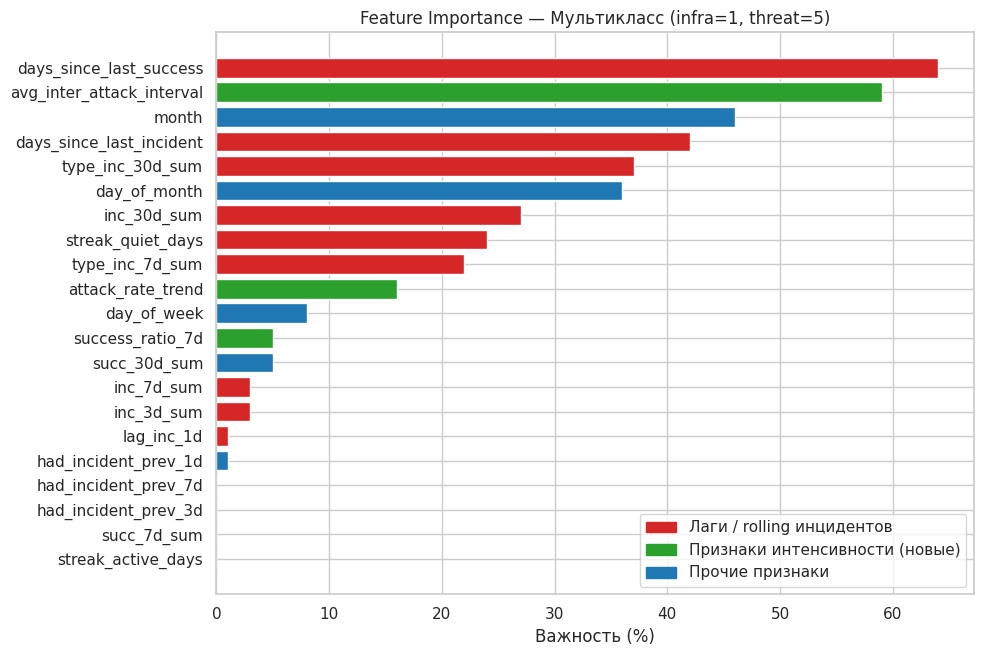

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,64,1,5
1,avg_inter_attack_interval,59,1,5
2,month,46,1,5
3,days_since_last_incident,42,1,5
4,type_inc_30d_sum,37,1,5
5,day_of_month,36,1,5
6,inc_30d_sum,27,1,5
7,streak_quiet_days,24,1,5
8,type_inc_7d_sum,22,1,5
9,attack_rate_trend,16,1,5



Feature Importance (infra=1, threat=6):


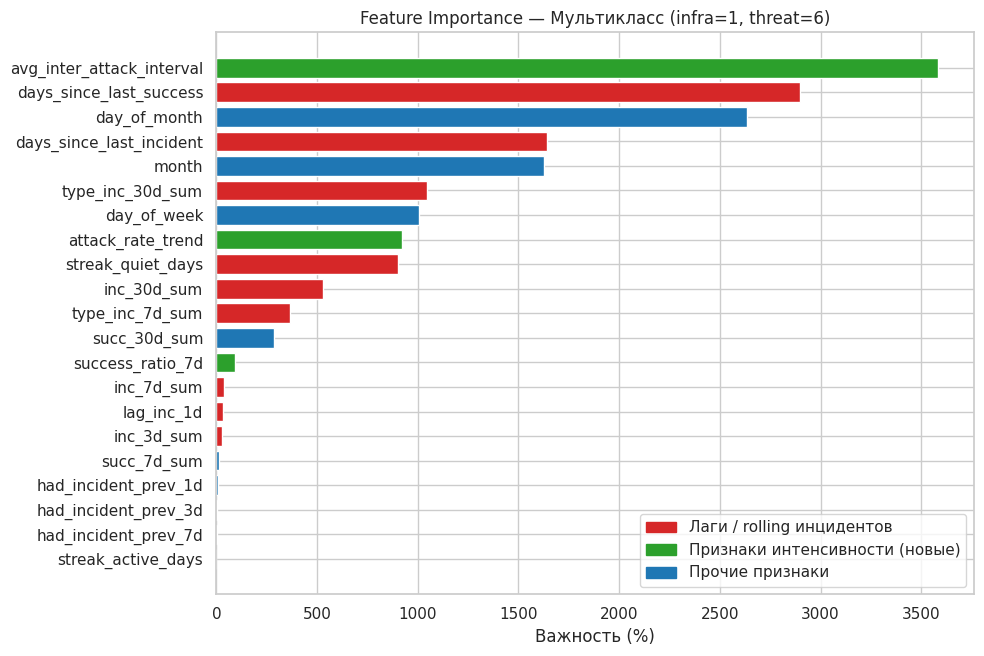

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,3583,1,6
1,days_since_last_success,2898,1,6
2,day_of_month,2634,1,6
3,days_since_last_incident,1643,1,6
4,month,1626,1,6
5,type_inc_30d_sum,1044,1,6
6,day_of_week,1004,1,6
7,attack_rate_trend,923,1,6
8,streak_quiet_days,903,1,6
9,inc_30d_sum,530,1,6



Feature Importance (infra=2, threat=1):


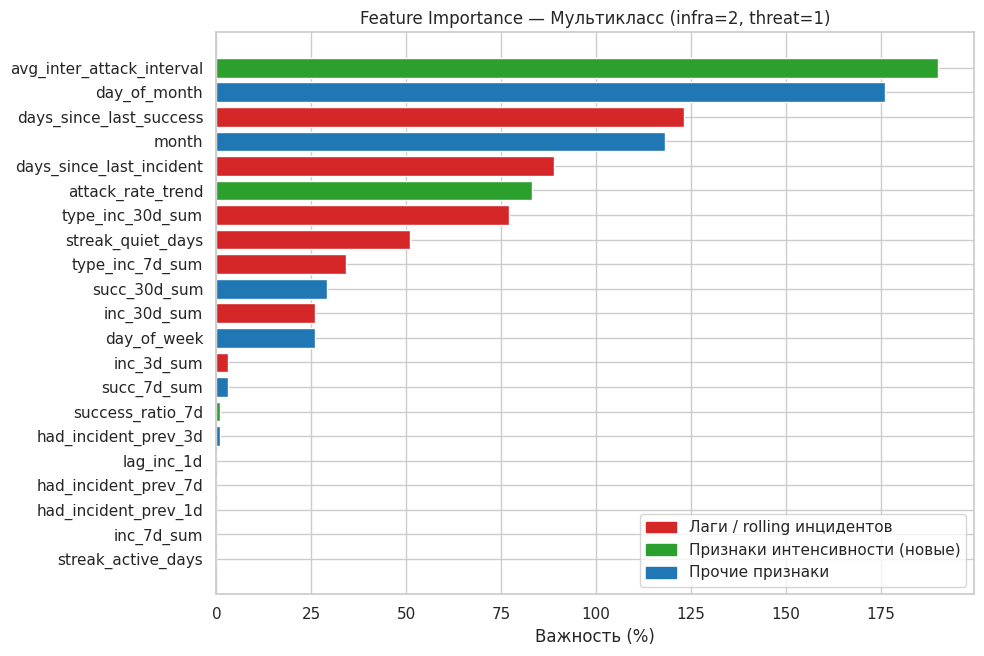

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,190,2,1
1,day_of_month,176,2,1
2,days_since_last_success,123,2,1
3,month,118,2,1
4,days_since_last_incident,89,2,1
5,attack_rate_trend,83,2,1
6,type_inc_30d_sum,77,2,1
7,streak_quiet_days,51,2,1
8,type_inc_7d_sum,34,2,1
9,succ_30d_sum,29,2,1



Feature Importance (infra=2, threat=2):


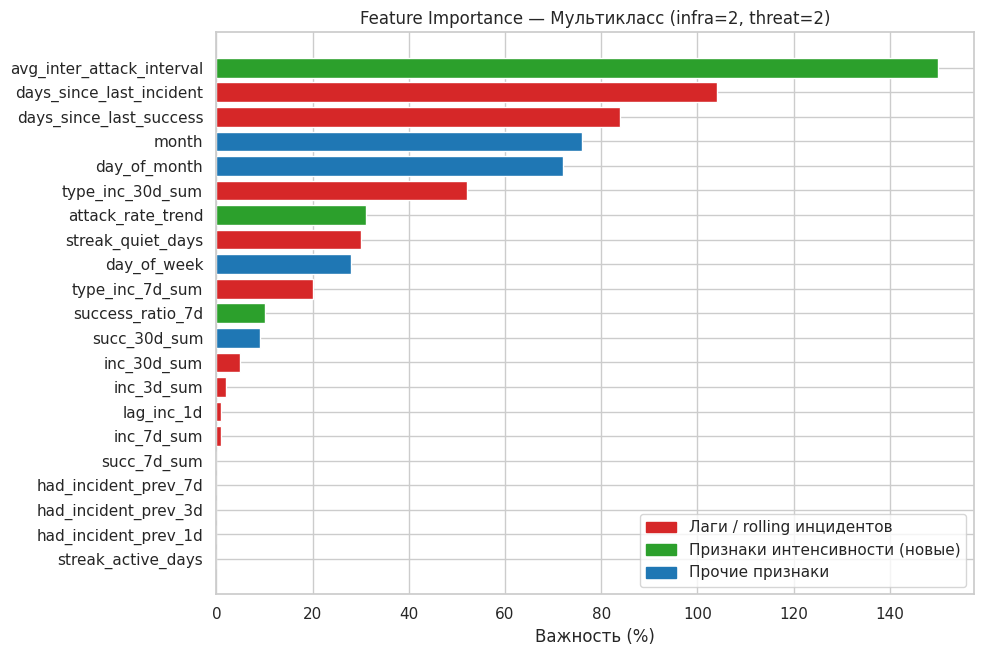

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,150,2,2
1,days_since_last_incident,104,2,2
2,days_since_last_success,84,2,2
3,month,76,2,2
4,day_of_month,72,2,2
5,type_inc_30d_sum,52,2,2
6,attack_rate_trend,31,2,2
7,streak_quiet_days,30,2,2
8,day_of_week,28,2,2
9,type_inc_7d_sum,20,2,2



Feature Importance (infra=2, threat=3):


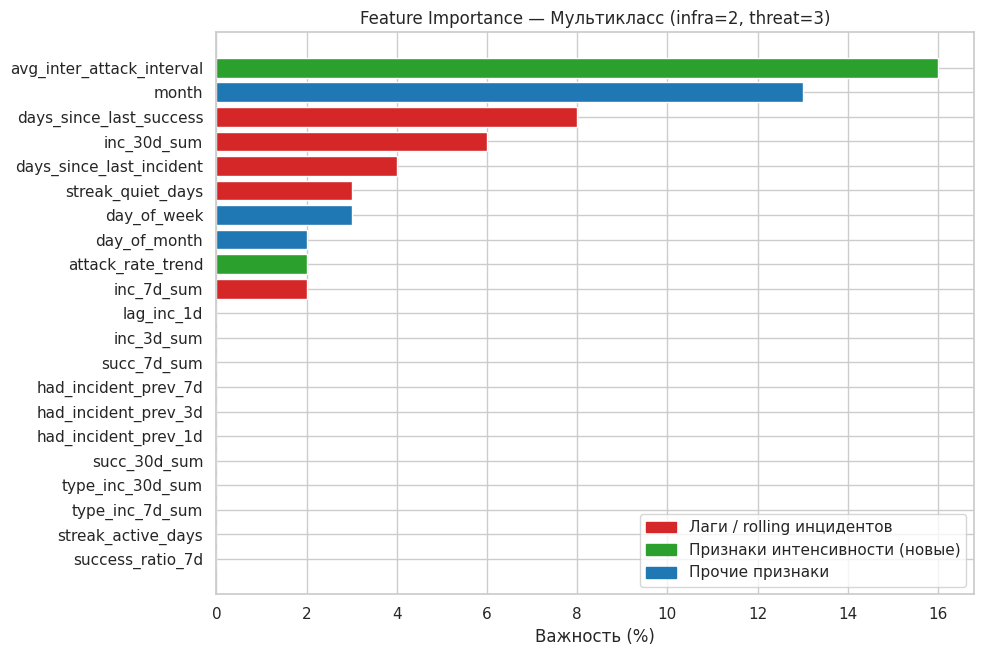

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,16,2,3
1,month,13,2,3
2,days_since_last_success,8,2,3
3,inc_30d_sum,6,2,3
4,days_since_last_incident,4,2,3
5,streak_quiet_days,3,2,3
6,day_of_week,3,2,3
7,day_of_month,2,2,3
8,attack_rate_trend,2,2,3
9,inc_7d_sum,2,2,3



Feature Importance (infra=2, threat=4):


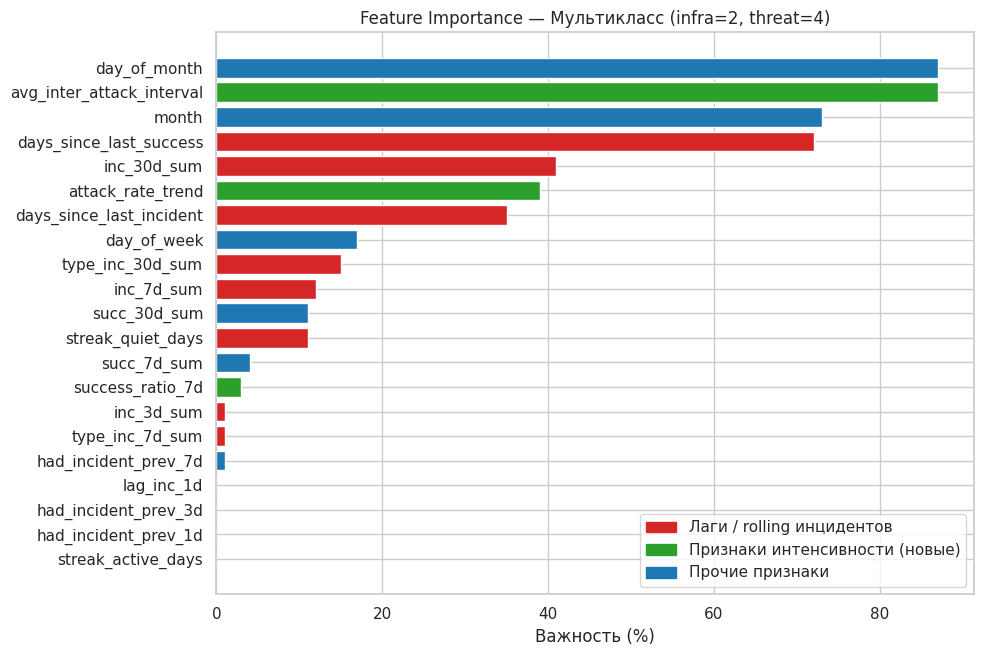

Топ-10 признаков:


,feature,importance,infra,threat
0,day_of_month,87,2,4
1,avg_inter_attack_interval,87,2,4
2,month,73,2,4
3,days_since_last_success,72,2,4
4,inc_30d_sum,41,2,4
5,attack_rate_trend,39,2,4
6,days_since_last_incident,35,2,4
7,day_of_week,17,2,4
8,type_inc_30d_sum,15,2,4
9,inc_7d_sum,12,2,4



Feature Importance (infra=2, threat=5):


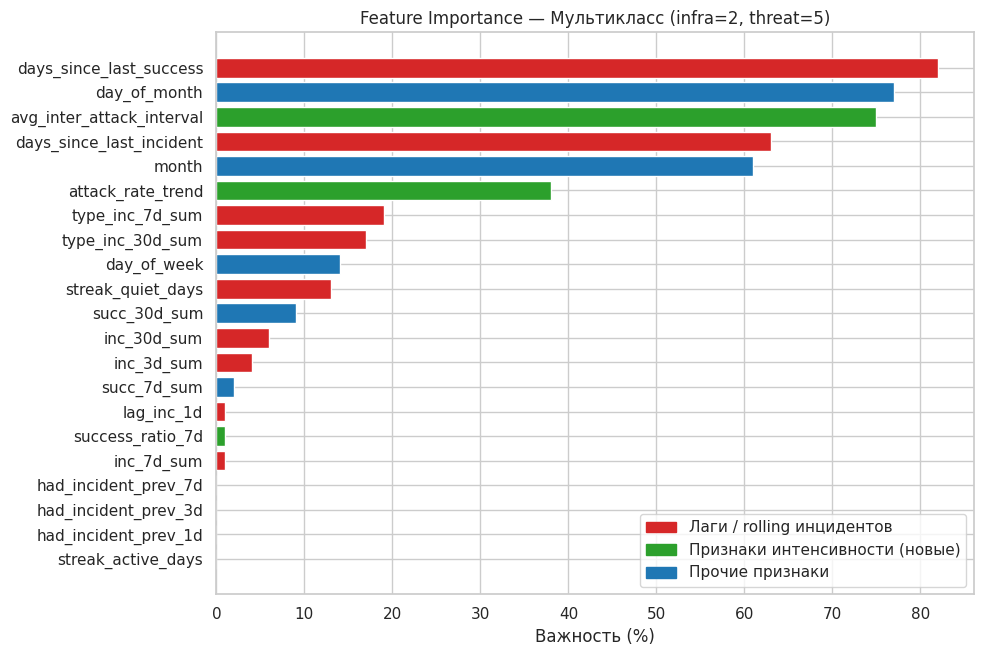

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,82,2,5
1,day_of_month,77,2,5
2,avg_inter_attack_interval,75,2,5
3,days_since_last_incident,63,2,5
4,month,61,2,5
5,attack_rate_trend,38,2,5
6,type_inc_7d_sum,19,2,5
7,type_inc_30d_sum,17,2,5
8,day_of_week,14,2,5
9,streak_quiet_days,13,2,5



Feature Importance (infra=2, threat=6):


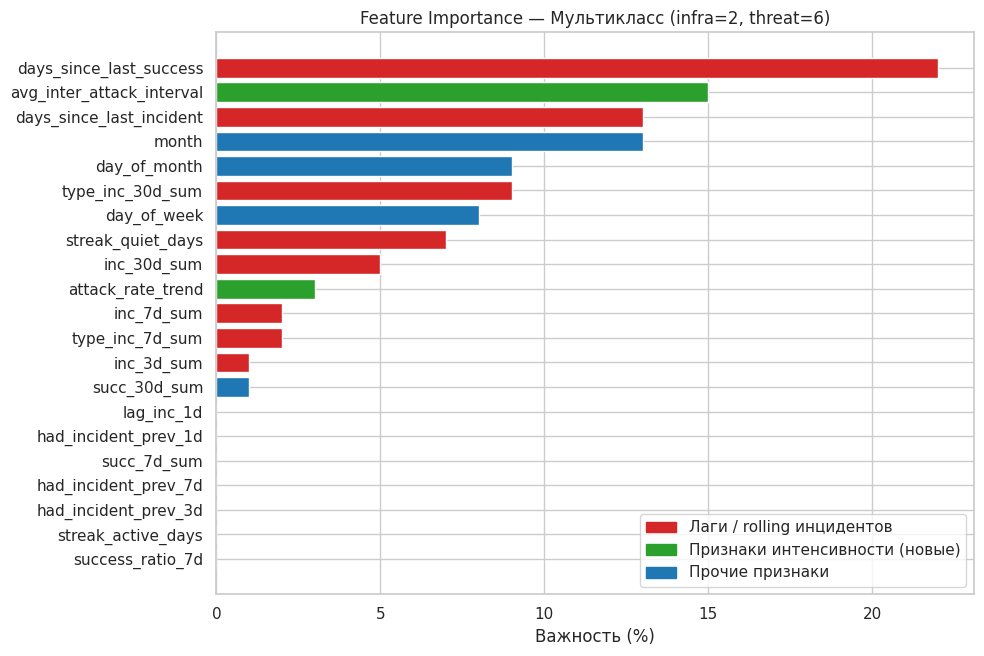

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,22,2,6
1,avg_inter_attack_interval,15,2,6
2,days_since_last_incident,13,2,6
3,month,13,2,6
4,day_of_month,9,2,6
5,type_inc_30d_sum,9,2,6
6,day_of_week,8,2,6
7,streak_quiet_days,7,2,6
8,inc_30d_sum,5,2,6
9,attack_rate_trend,3,2,6



Feature Importance (infra=3, threat=1):


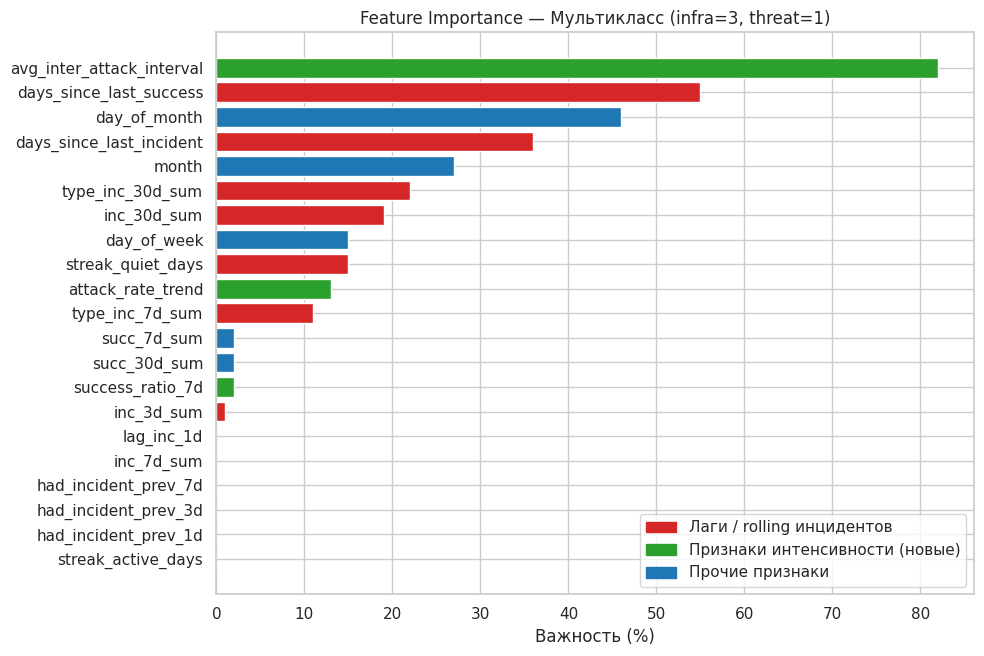

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,82,3,1
1,days_since_last_success,55,3,1
2,day_of_month,46,3,1
3,days_since_last_incident,36,3,1
4,month,27,3,1
5,type_inc_30d_sum,22,3,1
6,inc_30d_sum,19,3,1
7,day_of_week,15,3,1
8,streak_quiet_days,15,3,1
9,attack_rate_trend,13,3,1



Feature Importance (infra=3, threat=2):


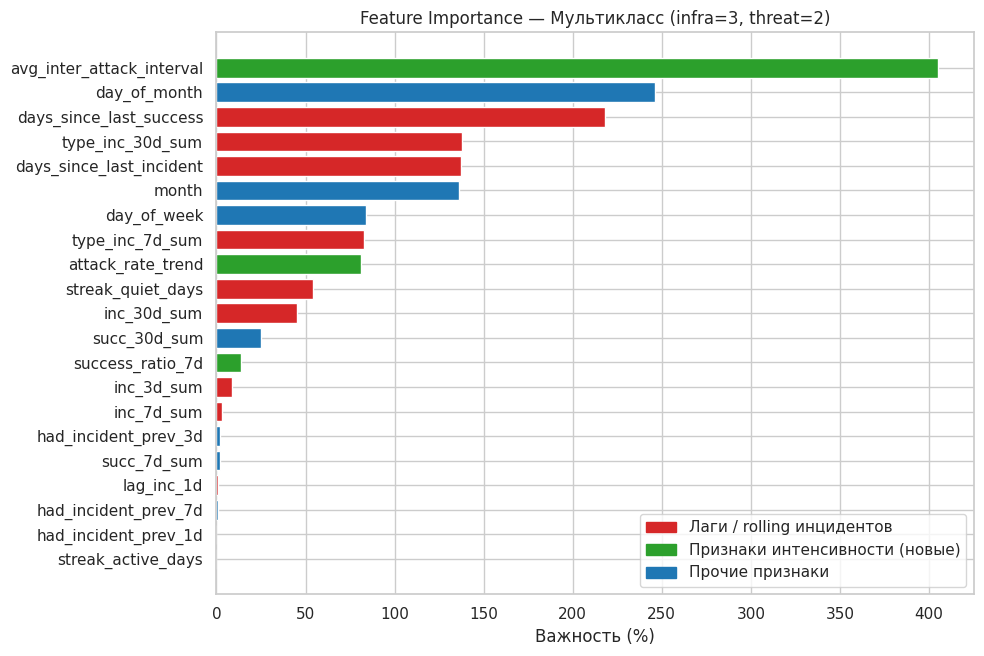

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,405,3,2
1,day_of_month,246,3,2
2,days_since_last_success,218,3,2
3,type_inc_30d_sum,138,3,2
4,days_since_last_incident,137,3,2
5,month,136,3,2
6,day_of_week,84,3,2
7,type_inc_7d_sum,83,3,2
8,attack_rate_trend,81,3,2
9,streak_quiet_days,54,3,2



Feature Importance (infra=3, threat=3):


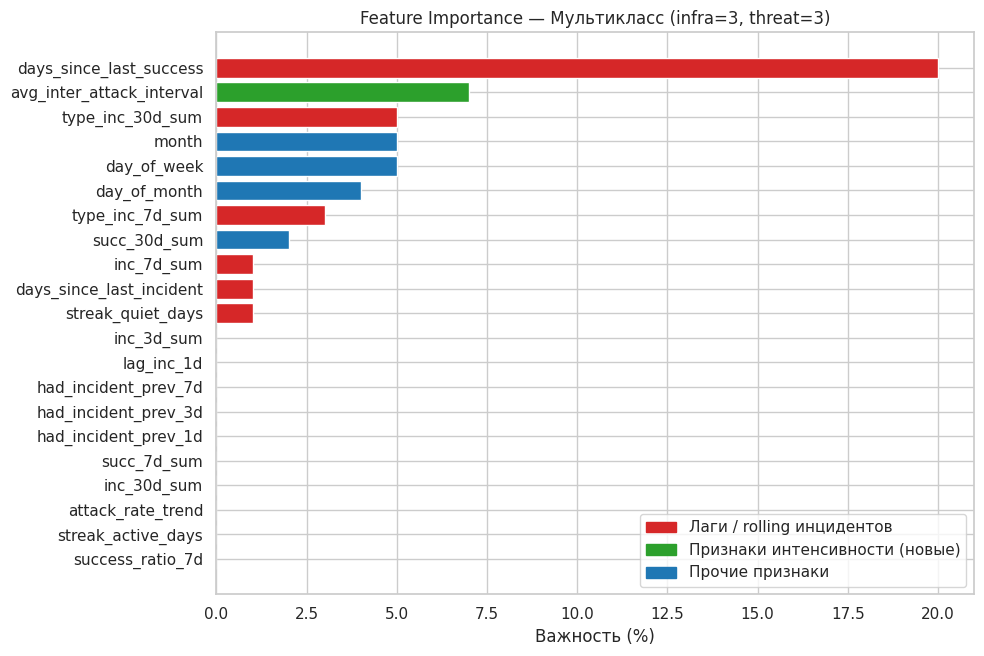

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,20,3,3
1,avg_inter_attack_interval,7,3,3
2,type_inc_30d_sum,5,3,3
3,month,5,3,3
4,day_of_week,5,3,3
5,day_of_month,4,3,3
6,type_inc_7d_sum,3,3,3
7,succ_30d_sum,2,3,3
8,inc_7d_sum,1,3,3
9,days_since_last_incident,1,3,3



Feature Importance (infra=3, threat=4):


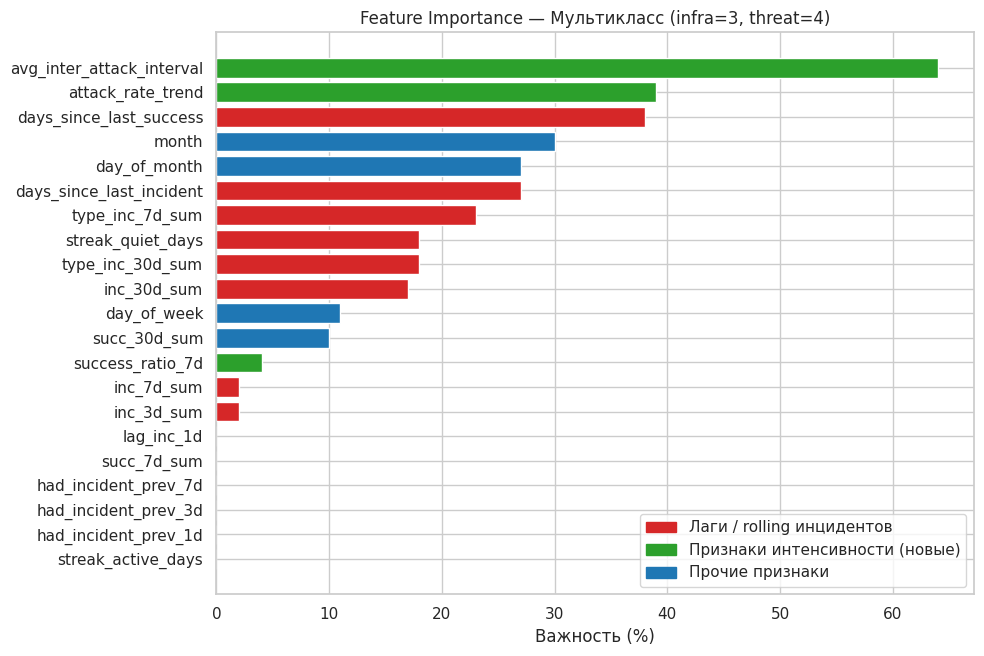

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,64,3,4
1,attack_rate_trend,39,3,4
2,days_since_last_success,38,3,4
3,month,30,3,4
4,day_of_month,27,3,4
5,days_since_last_incident,27,3,4
6,type_inc_7d_sum,23,3,4
7,streak_quiet_days,18,3,4
8,type_inc_30d_sum,18,3,4
9,inc_30d_sum,17,3,4



Feature Importance (infra=3, threat=5):


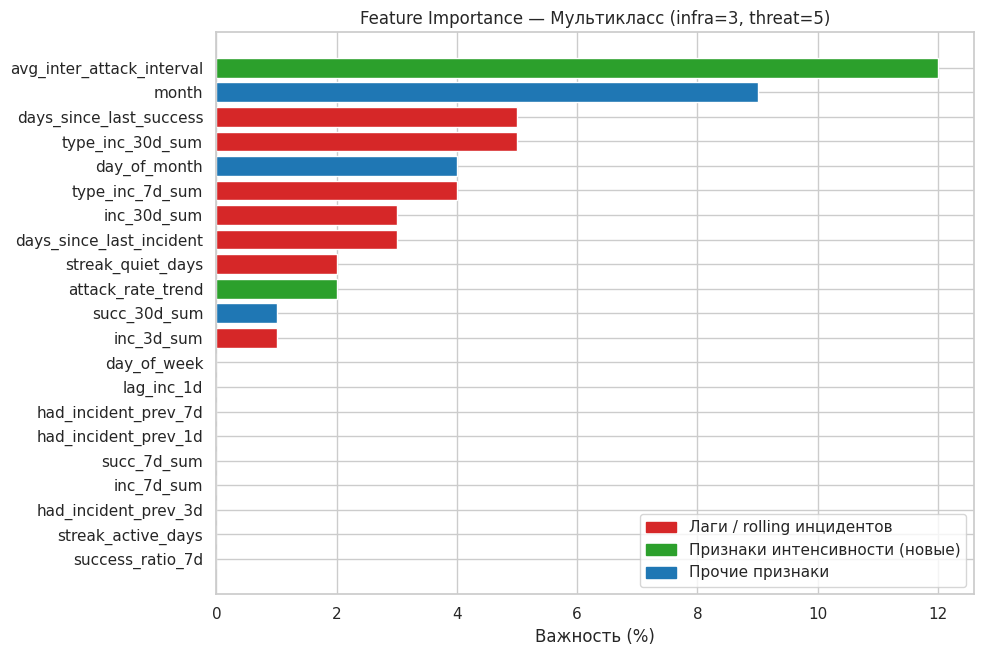

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,12,3,5
1,month,9,3,5
2,days_since_last_success,5,3,5
3,type_inc_30d_sum,5,3,5
4,day_of_month,4,3,5
5,type_inc_7d_sum,4,3,5
6,inc_30d_sum,3,3,5
7,days_since_last_incident,3,3,5
8,streak_quiet_days,2,3,5
9,attack_rate_trend,2,3,5



Feature Importance (infra=3, threat=6):


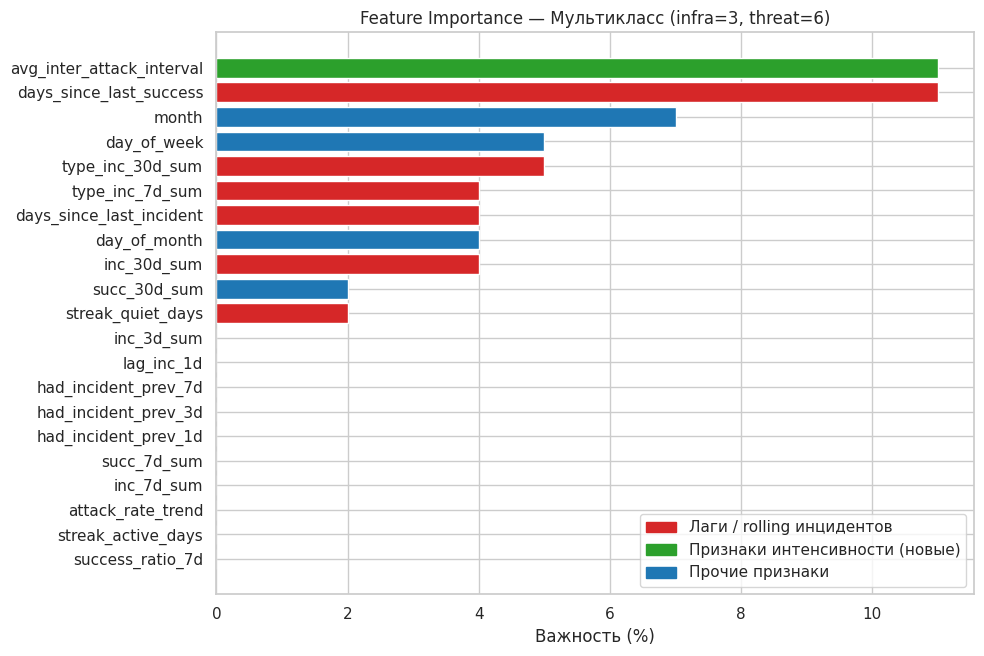

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,11,3,6
1,days_since_last_success,11,3,6
2,month,7,3,6
3,day_of_week,5,3,6
4,type_inc_30d_sum,5,3,6
5,type_inc_7d_sum,4,3,6
6,days_since_last_incident,4,3,6
7,day_of_month,4,3,6
8,inc_30d_sum,4,3,6
9,succ_30d_sum,2,3,6



Feature Importance (infra=4, threat=1):


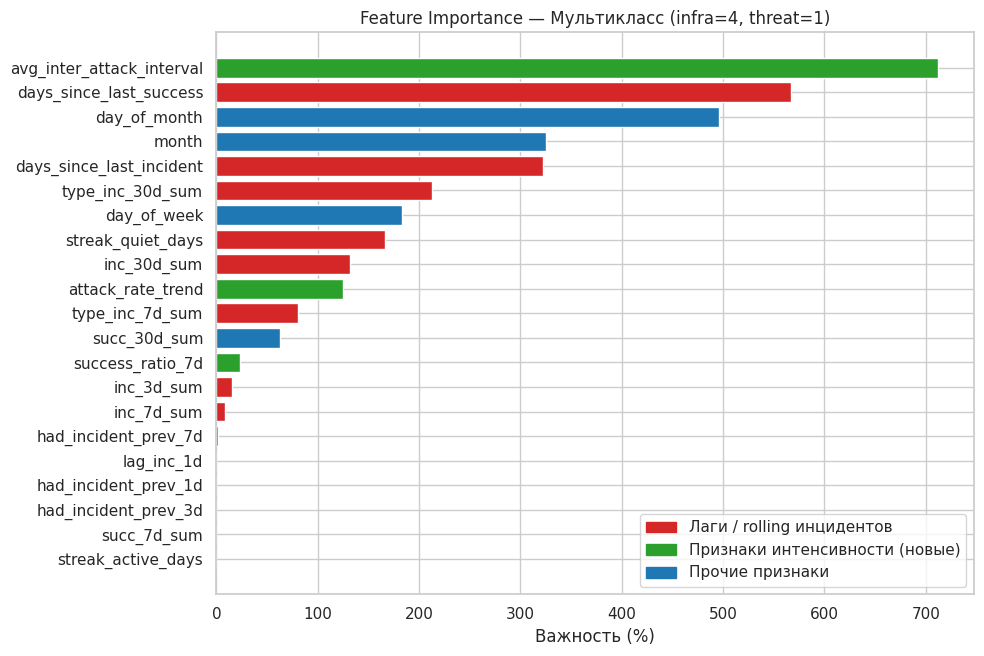

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,712,4,1
1,days_since_last_success,567,4,1
2,day_of_month,496,4,1
3,month,325,4,1
4,days_since_last_incident,322,4,1
5,type_inc_30d_sum,213,4,1
6,day_of_week,183,4,1
7,streak_quiet_days,166,4,1
8,inc_30d_sum,132,4,1
9,attack_rate_trend,125,4,1



Feature Importance (infra=4, threat=2):


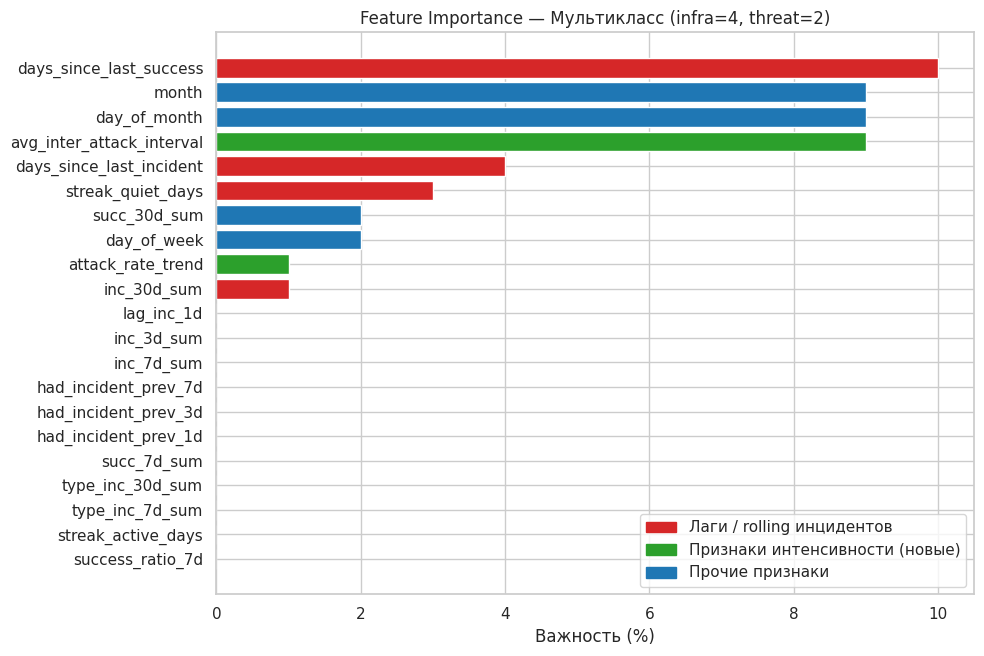

Топ-10 признаков:


,feature,importance,infra,threat
0,days_since_last_success,10,4,2
1,month,9,4,2
2,day_of_month,9,4,2
3,avg_inter_attack_interval,9,4,2
4,days_since_last_incident,4,4,2
5,streak_quiet_days,3,4,2
6,succ_30d_sum,2,4,2
7,day_of_week,2,4,2
8,attack_rate_trend,1,4,2
9,inc_30d_sum,1,4,2



Feature Importance (infra=4, threat=3):


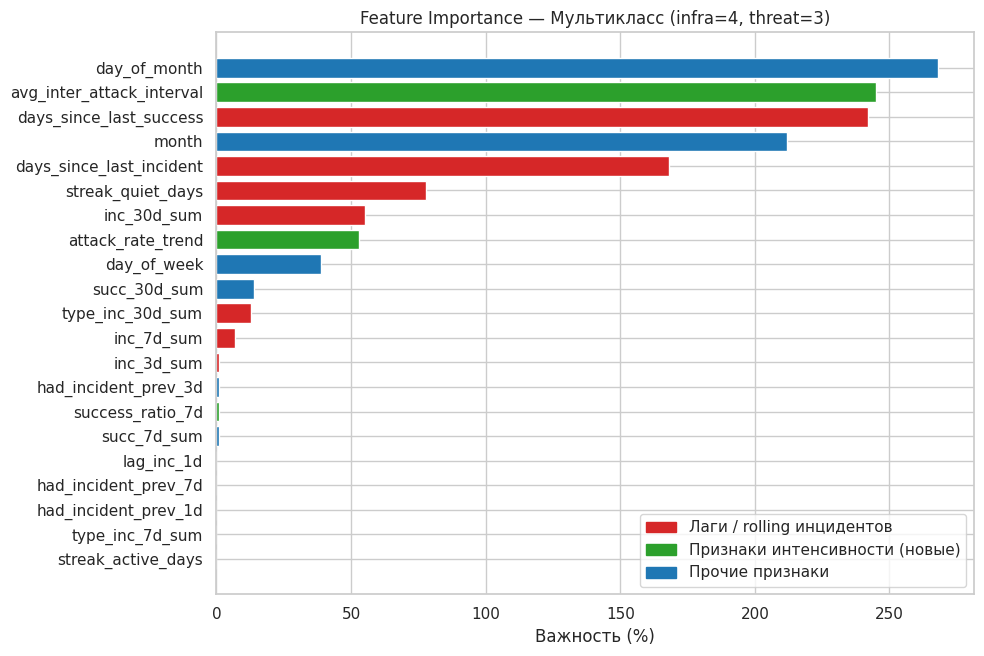

Топ-10 признаков:


,feature,importance,infra,threat
0,day_of_month,268,4,3
1,avg_inter_attack_interval,245,4,3
2,days_since_last_success,242,4,3
3,month,212,4,3
4,days_since_last_incident,168,4,3
5,streak_quiet_days,78,4,3
6,inc_30d_sum,55,4,3
7,attack_rate_trend,53,4,3
8,day_of_week,39,4,3
9,succ_30d_sum,14,4,3



Feature Importance (infra=4, threat=4):


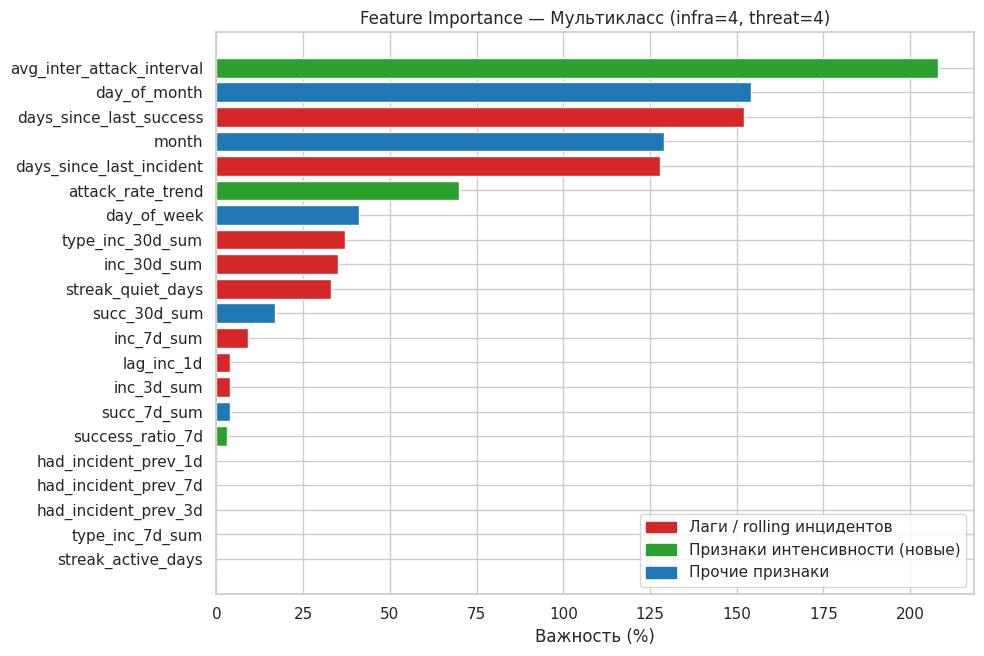

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,208,4,4
1,day_of_month,154,4,4
2,days_since_last_success,152,4,4
3,month,129,4,4
4,days_since_last_incident,128,4,4
5,attack_rate_trend,70,4,4
6,day_of_week,41,4,4
7,type_inc_30d_sum,37,4,4
8,inc_30d_sum,35,4,4
9,streak_quiet_days,33,4,4



Feature Importance (infra=4, threat=5):


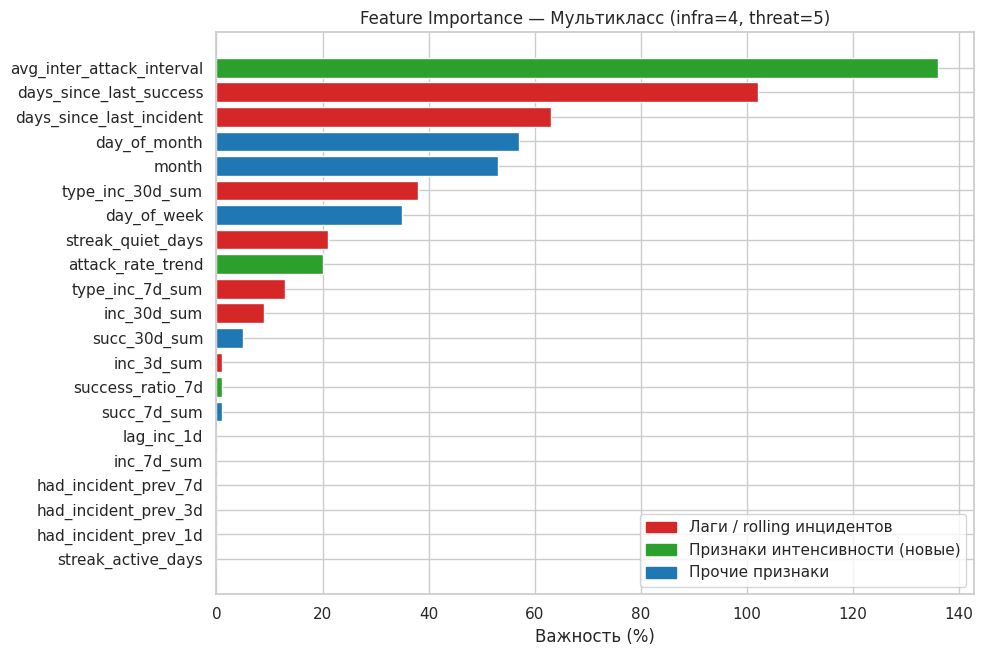

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,136,4,5
1,days_since_last_success,102,4,5
2,days_since_last_incident,63,4,5
3,day_of_month,57,4,5
4,month,53,4,5
5,type_inc_30d_sum,38,4,5
6,day_of_week,35,4,5
7,streak_quiet_days,21,4,5
8,attack_rate_trend,20,4,5
9,type_inc_7d_sum,13,4,5



Feature Importance (infra=4, threat=6):


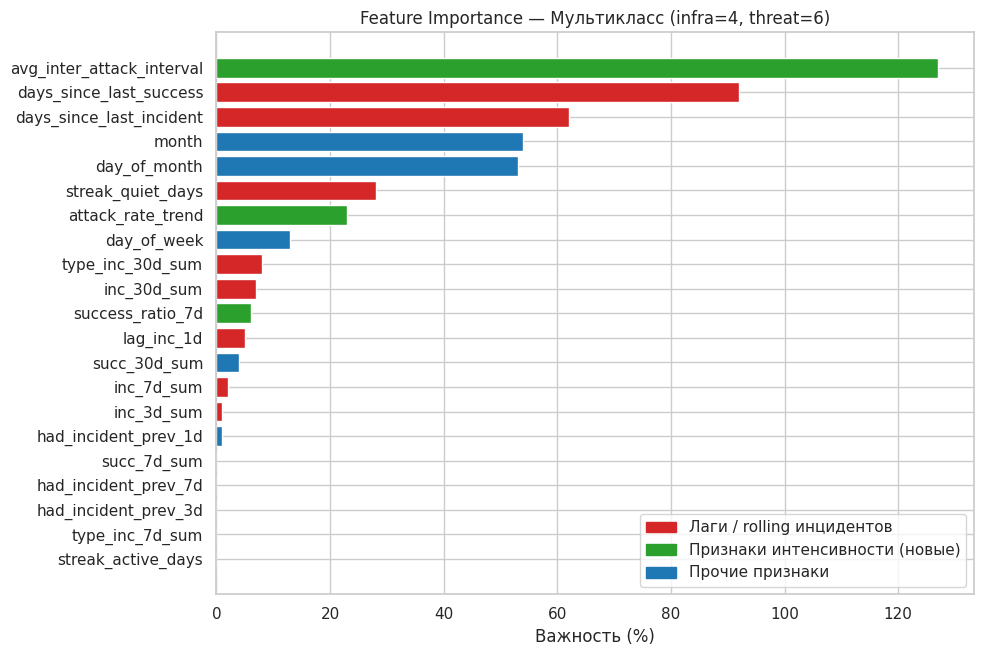

Топ-10 признаков:


,feature,importance,infra,threat
0,avg_inter_attack_interval,127,4,6
1,days_since_last_success,92,4,6
2,days_since_last_incident,62,4,6
3,month,54,4,6
4,day_of_month,53,4,6
5,streak_quiet_days,28,4,6
6,attack_rate_trend,23,4,6
7,day_of_week,13,4,6
8,type_inc_30d_sum,8,4,6
9,inc_30d_sum,7,4,6



Общая таблица importance по всем моделям:


,feature,importance,infra,threat
0,avg_inter_attack_interval,278,1,1
1,day_of_month,212,1,1
2,days_since_last_success,203,1,1
3,days_since_last_incident,148,1,1
4,month,105,1,1
...,...,...,...,...
499,succ_7d_sum,0,4,6
500,had_incident_prev_7d,0,4,6
501,had_incident_prev_3d,0,4,6
502,type_inc_7d_sum,0,4,6


In [13]:
if models_mc:
    all_importance = []

    for model_key, model in models_mc.items():
        infra, threat = model_key

        importance_df = pd.DataFrame({
            'feature': model.feature_name_,
            'importance': model.booster_.feature_importance()
        }).sort_values('importance', ascending=False).reset_index(drop=True)

        importance_df['infra'] = infra
        importance_df['threat'] = threat

        all_importance.append(importance_df)

        print(f"\nFeature Importance (infra={infra}, threat={threat}):")

        fig, ax = plt.subplots(figsize=(10, max(6, len(importance_df) * 0.32)))

        colors = [
            '#d62728' if any(kw in f for kw in ['inc_', 'days_since', 'streak', 'lag_days'])
            else '#2ca02c' if any(kw in f for kw in ['attack_rate', 'success_ratio', 'avg_inter'])
            else '#1f77b4'
            for f in importance_df['feature']
        ]

        ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
        ax.invert_yaxis()
        ax.set_title(f'Feature Importance — Мультикласс (infra={infra}, threat={threat})')
        ax.set_xlabel('Важность (%)')

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(color='#d62728', label='Лаги / rolling инцидентов'),
            Patch(color='#2ca02c', label='Признаки интенсивности (новые)'),
            Patch(color='#1f77b4', label='Прочие признаки'),
        ]
        ax.legend(handles=legend_elements, loc='lower right')

        plt.tight_layout()
        plt.show()

        print("Топ-10 признаков:")
        display(importance_df.head(10))

    all_importance_df = pd.concat(all_importance, ignore_index=True)

    print("\nОбщая таблица importance по всем моделям:")
    display(all_importance_df)

## 11. Вероятности по классам (вместо жёсткого предсказания)

Вместо одного класса модель возвращает распределение вероятностей по всем 5 классам.
Это позволяет реализовать более тонкое управление оповещениями:
- P(class=0) > 0.4 → немедленная тревога
- P(class=0) + P(class=1) > 0.6 → повышенная готовность


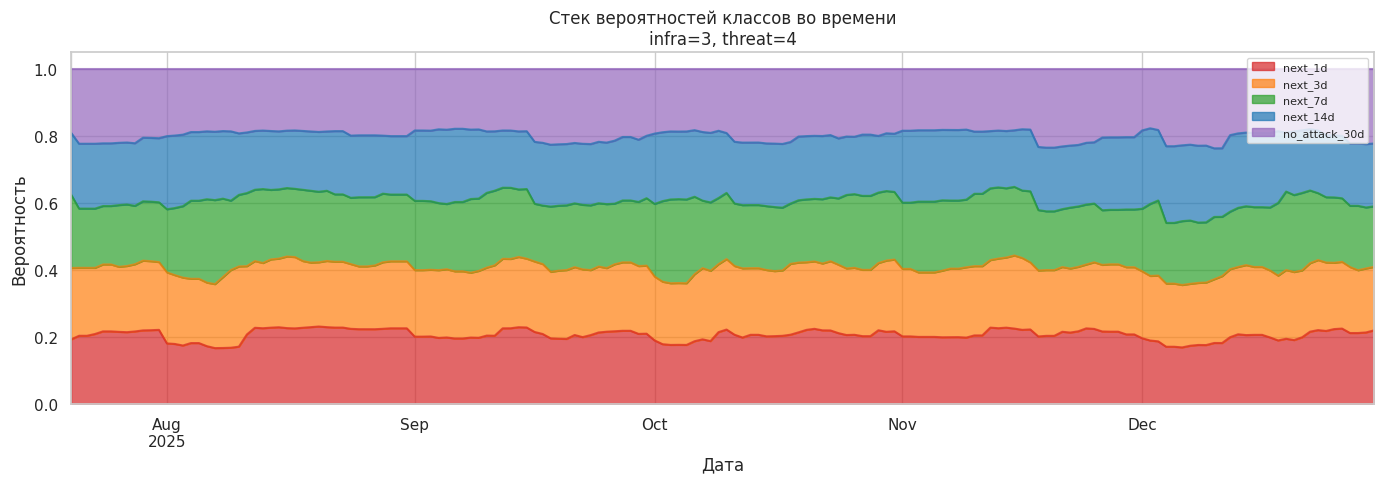


Пример: первые 5 предсказаний с вероятностями:


,next_1d,next_3d,next_7d,next_14d,no_attack_30d,predicted_class,predicted_label
2025-07-20,0.192,0.214,0.219,0.184,0.190,2,next_7d
2025-07-21,0.203,0.203,0.177,0.194,0.223,4,no_attack_30d
2025-07-22,0.203,0.203,0.177,0.194,0.223,4,no_attack_30d
2025-07-23,0.209,0.197,0.177,0.194,0.223,4,no_attack_30d
2025-07-24,0.216,0.200,0.174,0.187,0.222,4,no_attack_30d


In [14]:
if len(results_mc) > 0:
    best_row  = results_mc.loc[results_mc['test_macro_f1'].idxmax()]
    infra_v   = str(best_row['infrastructure_cluster'])
    threat_v  = int(best_row['threat_cluster'])
    model     = models_mc[(infra_v, threat_v)]

    part = dataset_model[
        (dataset_model['infrastructure_cluster'].astype(str) == infra_v) &
        (dataset_model['threat_cluster'].astype(int) == threat_v)
    ].copy().sort_values('date').reset_index(drop=True)

    unique_dates = np.array(sorted(part['date'].unique()))
    n = len(unique_dates)
    test_dates = unique_dates[int(n * 0.85):]
    test_df = add_rolling(part[part['date'].isin(test_dates)].copy())

    avail_feats = [f for f in feature_cols if f in test_df.columns]
    X_test = test_df[avail_feats].copy()
    for c in [c for c in cat_features if c in X_test.columns]:
        X_test[c] = X_test[c].astype(str)

    proba = model.predict_proba(X_test)  # shape: (n_rows, 5)

    # Строим стековый area-chart вероятностей во времени
    proba_df = pd.DataFrame(
        proba,
        columns=[ATTACK_WINDOW_LABELS[i] for i in range(N_CLASSES)],
        index=test_df['date'].values
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    proba_df.plot.area(ax=ax, alpha=0.7, color=['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd'])
    ax.set_title(f'Стек вероятностей классов во времени\ninfra={infra_v}, threat={threat_v}')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Вероятность')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nПример: первые 5 предсказаний с вероятностями:")
    sample = proba_df.head(5).round(3)
    sample['predicted_class'] = model.predict(X_test.head(5)).flatten().astype(int)
    sample['predicted_label'] = sample['predicted_class'].map(ATTACK_WINDOW_LABELS)
    display(sample)


In [15]:
proba_df

,next_1d,next_3d,next_7d,next_14d,no_attack_30d
2025-07-20,0.192044,0.213614,0.219394,0.184451,0.190497
2025-07-21,0.203219,0.202867,0.176836,0.193627,0.223450
2025-07-22,0.203219,0.202867,0.176836,0.193627,0.223450
2025-07-23,0.208561,0.197445,0.176860,0.193654,0.223481
2025-07-24,0.216361,0.199825,0.174474,0.187130,0.222210
...,...,...,...,...,...
2025-12-26,0.224738,0.199221,0.189819,0.186320,0.199902
2025-12-27,0.211453,0.196977,0.182789,0.186039,0.222743
2025-12-28,0.211484,0.187400,0.192274,0.186067,0.222776
2025-12-29,0.213162,0.191072,0.182126,0.189095,0.224544


## 12. Сохранение моделей

In [16]:
PROJECT_ROOT = Path('..').resolve()
MVP_DIR  = PROJECT_ROOT / 'ml'
MC_DIR   = MVP_DIR / 'models' / 'v1' / 'multiclass' / 'lgbm'
MC_DIR.mkdir(parents=True, exist_ok=True)

for (infra, threat), model in models_mc.items():
    model.booster_.save_model(str(MC_DIR / f"lgbm_{infra}_{threat}.cbm"))

print(f"Сохранено мультиклассовых моделей: {len(models_mc)} → {MC_DIR}")

results_mc.to_csv(MVP_DIR / 'models' / 'v1' / 'multiclass' / 'results_lgbm.csv', index=False)
print(f"Таблица результатов: {MVP_DIR / 'models' / 'v1' / 'multiclass' / 'results_lgbm.csv'}")

# Метаданные
import json as json_mod
mc_meta = {
    'task': 'multiclass_classification',
    'target_col': TARGET_COL,
    'n_classes': N_CLASSES,
    'class_labels': ATTACK_WINDOW_LABELS,
    'feature_cols': feature_cols,
    'cat_features': cat_features,
    'models': [f"{k[0]}_{k[1]}" for k in models_mc.keys()]
}
with open(MVP_DIR / 'models' / 'v1' / 'multiclass' / 'meta_lgbm.json', 'w') as f:
    json_mod.dump(mc_meta, f, ensure_ascii=False, indent=2)

print("Метаданные: meta_lgbm.json")


Сохранено мультиклассовых моделей: 24 → /home/max/projects/rsm_hackathon_2026/ml/models/v1/multiclass/lgbm
Таблица результатов: /home/max/projects/rsm_hackathon_2026/ml/models/v1/multiclass/results_lgbm.csv
Метаданные: meta_lgbm.json


## 13. Утилита инференса

In [17]:
def predict_attack_window(
    infra_cluster: int,
    threat_cluster: int,
    feature_values: dict,
    models_dir: Path = Path('..') / 'ml' / 'models' / 'v1' / 'multiclass' / 'lgbm'
) -> dict:
    """
    Предсказать, в каком временном окне ожидается следующая атака.

    Возвращает predicted_class, predicted_label и вероятности по всем классам.
    """
    model_path = models_dir / f"{infra_cluster}_{threat_cluster}.cbm"
    if not model_path.exists():
        return {'error': f'Модель не найдена: {model_path}'}

    model = cb.CatBoostClassifier()
    model.load_model(str(model_path))

    X = pd.DataFrame([feature_values])
    for col in cat_features:
        if col in X.columns:
            X[col] = X[col].astype(str)

    pred_class = int(model.predict(X).flatten()[0])
    proba      = model.predict_proba(X).flatten()

    return {
        'infrastructure_cluster': infra_cluster,
        'threat_cluster': threat_cluster,
        'predicted_class': pred_class,
        'predicted_label': ATTACK_WINDOW_LABELS[pred_class],
        'probabilities': {ATTACK_WINDOW_LABELS[i]: round(float(proba[i]), 4)
                          for i in range(N_CLASSES)},
        'urgency_score': round(float(
            proba[0] * 1.0 + proba[1] * 0.75 + proba[2] * 0.5 + proba[3] * 0.25
        ), 4)  # взвешенный «индекс срочности» 0..1
    }

# Пример
if models_mc:
    key = list(models_mc.keys())[0]
    part = dataset_model[
        (dataset_model['infrastructure_cluster'].astype(str) == key[0]) &
        (dataset_model['threat_cluster'].astype(int) == key[1])
    ].iloc[-3]

    feat_dict = {f: part[f] for f in feature_cols if f in part.index}
    result = predict_attack_window(key[0], key[1], feat_dict)
    print("Пример предсказания:")
    for k, v in result.items():
        print(f"  {k}: {v}")


Пример предсказания:
  error: Модель не найдена: ../ml/models/v1/multiclass/lgbm/1_1.cbm


## 14. Итоги

### Что сделано:

1. Обучены **CatBoostClassifier (MultiClass)** для каждого сегмента (infrastructure × threat)
2. Целевая переменная: `attack_window_class` — временное окно до ближайшей атаки (5 классов)
3. Применены **сбалансированные веса классов** для компенсации дисбаланса
4. Оценка: Macro F1, Weighted F1, Accuracy, per-class Recall
5. Построены Confusion Matrix и вероятностные прогнозы
6. Реализована утилита **`predict_attack_window`** с `urgency_score`

### Ключевые метрики:

| Задача | Моделей | Macro F1 (среднее) | Recall cls0 (среднее) |
|--------|---------|--------------------|-----------------------|
| Мультикласс | — | — | — |

*(заполнится после выполнения)*

### Карта задач:

```
02_feature_engineering_v2.ipynb  ─────────┐
                                           ↓
                              dataset_features.parquet
                                           ↓
        ┌──────────────────────────────────┼─────────────────────────┐
        ↓                                  ↓                         ↓
03_model_training.ipynb          03_regression.ipynb      03_multiclass.ipynb
 Бинарная классификация         Регрессия (дней/часов до         Мультикласс (окна
  24h / 7d                        следующей атаки)            срочности)
```

